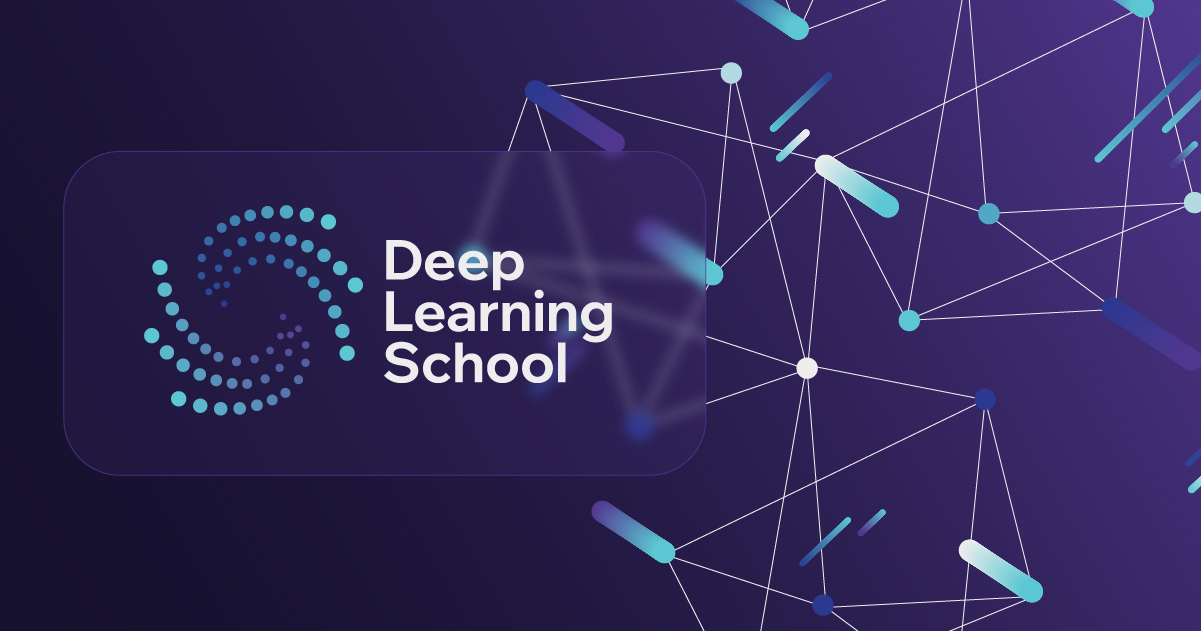

<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h1 style="text-align: center;"><b>Домашнее задание. Библиотека sklearn и классификация с помощью KNN</b></h1>

## Описание домашнего задания

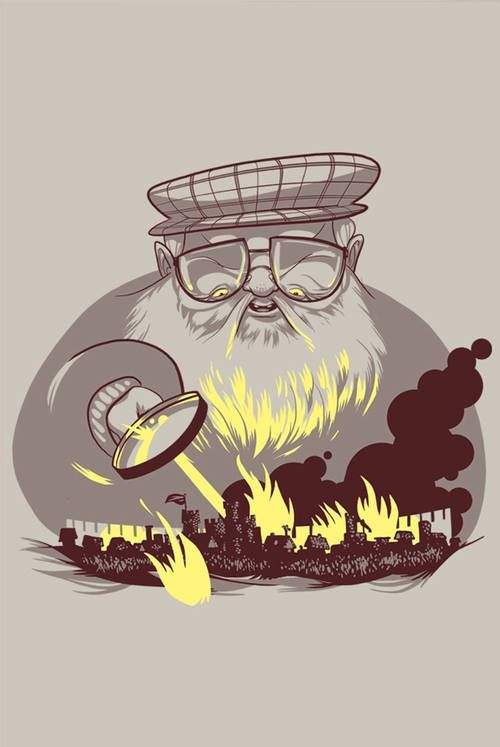

В данном задании вы будете работать с датасетом о персонажах из вселенной Игры Престолов [A Wiki of Ice and Fire](http://awoiaf.westeros.org/). Вам предстоит предсказать, кто из персонажей умрет, а кто останется вживых.



Описание данных:

* **name**: Имя персонажа

* **Title**: Социальный статус или знатность

* **House**: Дом, к которому принадлежит персонаж

* **Culture**: Социальная группа, к которой принадлежит персонаж

* **book1/2/3/4/5**: Появление персонажа в книге

* **Is noble**: Знатность персонажа, основанное на титуле

* **Age**: Отсчет времени: 305 AC

* **male**: Мужчина или женщина

* **dateOfBirth**: дата рождения

* **Spouse**: Имя супруги\а персонажа

* **Father**: Имя отца персонажа

* **Mother**: Имя матери персонажа

* **Heir**: Имя наследника персонажа

* **Is married**: Represents whether the character is married

* **Is spouse alive**: Represents whether character's spouse is alive

* **Is mother alive:** Жива ли мать персонажа

* **Is heir alive:** Жив ли наследник персонажа

* **Is father alive:** Указывает, жив ли отец персонажа

* **Number dead relations:** Количество умерших персонажей, с которыми персонаж связан

* **Popularity score:** Количество внутренних входящих и исходящих ссылок на страницу персонажей в вики http://awoiaf.westeros.org

Целевая переменная:
* **isAlive**: жив ли персонаж в книге

Оценивание:

Баллы считаются следующим образом:

1) $1.00 \geqslant score \geqslant 0.75$ --- 5 баллов

2) $0.75 > score \geqslant 0.65$ --- 4 балла

3) $0.65 > score \geqslant 0.55$ --- 3 балла

4) $0.55 > score \geqslant 0.50$ --- 2 балла

5) $0.50 > score \geqslant 0.45$ --- 1 балл

6) $0.45 > score$ --- 0 баллов

## Часть 1. Анализ и предобработка данных

Загружаем датасет

In [ ]:
!gdown 1h99toeF7lZ2I3iJwehgKO-QQmDaOe_O3
!gdown 1XL0VTygpZj-ZAuTNRBgApZTPQyNDnT-v

Downloading...
From: https://drive.google.com/uc?id=1h99toeF7lZ2I3iJwehgKO-QQmDaOe_O3
To: /content/game_of_thrones_test.csv
100% 37.3k/37.3k [00:00<00:00, 55.1MB/s]
Downloading...
From: https://drive.google.com/uc?id=1XL0VTygpZj-ZAuTNRBgApZTPQyNDnT-v
To: /content/game_of_thrones_train.csv
100% 138k/138k [00:00<00:00, 98.9MB/s]


Скачаем необходимые библиотеки

In [ ]:
!pip install -q catboost category_encoders optuna optuna-integration

Имортируем нужные библиотеки

In [ ]:
import numpy as np
import pandas as pd

from matplotlib import pyplot as plt
import seaborn as sns

from catboost import CatBoostClassifier

from category_encoders import CatBoostEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC, SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    BaggingClassifier,
    AdaBoostClassifier
)

import optuna
from optuna.integration import OptunaSearchCV

In [ ]:
sns.set_style('darkgrid')

Считаем датасеты в переменные train и test

In [ ]:
train = pd.read_csv('game_of_thrones_train.csv', index_col=0)
test = pd.read_csv('game_of_thrones_test.csv', index_col=0)

Посмотрим на сами датасеты

In [ ]:
train

,name,title,male,culture,dateOfBirth,mother,father,heir,house,spouse,...,isAliveMother,isAliveFather,isAliveHeir,isAliveSpouse,isMarried,isNoble,age,numDeadRelations,popularity,isAlive
S.No,,,,,,,,,,,,,,,,,,,,,
1,Viserys II Targaryen,NaN,1,NaN,NaN,Rhaenyra Targaryen,Daemon Targaryen,Aegon IV Targaryen,NaN,NaN,...,1.0,0.0,0.0,NaN,0,0,NaN,11,0.605351,0
2,Walder Frey,Lord of the Crossing,1,Rivermen,208.0,NaN,NaN,NaN,House Frey,Perra Royce,...,NaN,NaN,NaN,1.0,1,1,97.0,1,0.896321,1
3,Addison Hill,Ser,1,NaN,NaN,NaN,NaN,NaN,House Swyft,NaN,...,NaN,NaN,NaN,NaN,0,1,NaN,0,0.267559,1
4,Aemma Arryn,Queen,0,NaN,82.0,NaN,NaN,NaN,House Arryn,Viserys I Targaryen,...,NaN,NaN,NaN,0.0,1,1,23.0,0,0.183946,0
5,Sylva Santagar,Greenstone,0,Dornish,276.0,NaN,NaN,NaN,House Santagar,Eldon Estermont,...,NaN,NaN,NaN,1.0,1,1,29.0,0,0.043478,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1553,Marwyn,Archmaester,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0,1,NaN,0,0.160535,1
1554,Masha Heddle,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0,0,NaN,0,0.040134,0
1555,Matthos Seaworth,NaN,1,NaN,NaN,NaN,NaN,NaN,House Seaworth,NaN,...,NaN,NaN,NaN,NaN,0,0,NaN,0,0.076923,0


In [ ]:
test

,name,title,male,culture,dateOfBirth,mother,father,heir,house,spouse,...,book5,isAliveMother,isAliveFather,isAliveHeir,isAliveSpouse,isMarried,isNoble,age,numDeadRelations,popularity
S.No,,,,,,,,,,,,,,,,,,,,,
1558,Melissa Blackwood,NaN,0,NaN,156.0,NaN,NaN,NaN,House Blackwood,NaN,...,1,NaN,NaN,NaN,NaN,0,0,100.0,0,0.050167
1559,Melisandre,NaN,0,Asshai,NaN,NaN,NaN,NaN,R'hllor,NaN,...,1,NaN,NaN,NaN,NaN,0,0,NaN,0,0.745819
1560,Merrit,NaN,0,NaN,NaN,NaN,NaN,NaN,Brotherhood without banners,NaN,...,0,NaN,NaN,NaN,NaN,0,0,NaN,0,0.010033
1561,Meryn Trant,Ser,1,NaN,NaN,NaN,NaN,NaN,House Trant,NaN,...,1,NaN,NaN,NaN,NaN,0,1,NaN,0,0.220736
1562,Merrett Frey,NaN,1,Riverlands,262.0,NaN,NaN,NaN,House Frey,Mariya Darry,...,1,NaN,NaN,NaN,1.0,1,0,38.0,0,0.434783
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1942,Luwin,NaN,1,Westeros,NaN,NaN,NaN,NaN,House Stark,NaN,...,1,NaN,NaN,NaN,NaN,0,0,NaN,0,0.351171
1943,Reek,NaN,1,NaN,NaN,NaN,NaN,NaN,House Bolton,NaN,...,1,NaN,NaN,NaN,NaN,0,0,NaN,0,0.096990
1944,Symeon Star-Eyes,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1,NaN,NaN,NaN,NaN,0,0,NaN,0,0.030100


Начнём предобрабатывать данные, это будет кропотливая и потная работа

### Столбец title

Попробуем сократить количество категорий следующим образом - оставим только часть их титула, то есть, например, всех королей сделать просто королями, всех лордов - лордами, и так далее

Составим списки с заменами титулов

In [ ]:
ecclesiastic = ['Red Priest', 'Septa', 'Septon', 'Blue Grace', 'High Septon',
       'Green Grace']

king = ['Seven Kingdoms', 'King', 'King in the North',
       'King-Beyond-the-Wall', 'King of the Andals',
       'King of the Iron Islands', 'King of Astapor',
       'Lord of Kingsgrave', 'King of Winter']

lady = ['Lady', 'LadyQueenDowager Queen', 'LadyQueen', 'Lady Marya',
       "Lady of Torrhen's Square", 'Lady of Darry', 'Lady of the Leaves',
       'Lady of the Vale', 'Lady of Bear Island', 'Ironoaks', 'Deepwood Motte',
       'Old Oak', 'Iron Islands', 'Vaith', 'the Dreadfort', 'Haystack Hall',
       "Widow's Watch", 'Blackmont', 'Hayford', 'Godsgrace', 'Ghost Hill',
       'Goldengrove']

lord = ['Lord of the Crossing', 'Lord of the Iron Islands', 'Lord',
       'Lord of Coldmoat', 'Lord of the Tides', 'Lord of Dragonstone',
       'Lord Steward of the Iron Islands', 'Lord Paramount of the Mander',
       'Lord of Sunflower Hall', 'Lord of the Marches',
       'Lord of the Red Dunes', 'Lord Reaper of Pyke', 'Lord Seneschal',
       'Lord of Greyshield', "Lord Commander of the Night's Watch",
       'Lord of the Snakewood', 'Lord of Crows Nest',
       'Lord of the Deep Den', 'Lord of Darry',
       'Lord Paramount of the Trident', 'Lord of Pebbleton',
       'Lord of Atranta', 'Lord of Oldcastle', 'Lord of Southshield',
       "Lord of Flint's Finger",
       'Lord of the Ten TowersLord Harlaw of HarlawHarlaw of Harlaw',
       'The LiddleLord Liddle', 'Lord of the Tor', 'Lord of Iron Holt',
       'Lord of Honeyholt', 'Lord of Kingsgrave', 'Lord of Starfall',
       'Lord of Hellholt', 'Lord of Harrenhal', 'Lord of Oakenshield',
       'Lord of the Hornwood', 'Lord of Blackhaven',
       'The NorreyLord Norrey', 'Lord Steward', 'Lord of Hammerhorn',
       'LordWisdom', 'Lord Paramount of the Stormlands',
       'Lord of White Harbor', "Lord of Griffin's Roost",
       'Lord of the Seven Kingdoms', 'Quenten Banefort', 'Sandstone',
       'Strongsong', 'Claw Isle', 'Hornvale', 'Whitewalls', 'Terrence Kenning',
       'Sumner Crakehall', "Rook's Rest", 'Fair Isle', 'Coldwater Burn',
       'Maidenpool', 'Grey Glen', 'Three Sisters', 'Uplands', 'Sealskin Point',
       'Salt Shore', 'Keeper of the Gates of the Moon', 'Sandship', 'Rain House',
       'Blacktyde', 'Golden Storm', 'Horn Hill', 'Arbor', 'Greywater Watch',
       'Lonely Light', 'Stone Hedge', 'Oakenshield', 'Old Wyk', 'Bear Island',
       'Sandstone', 'Wyndhall', 'Rills', 'Longsister', 'Volmark', 'Greenshield',
       'Shatterstone', 'Pinkmaiden', 'Redfort', 'Goldgrass', 'Felwood',
       'Sweetport Sound', 'Sweetsister', 'Gulltown', 'Feastfires', 'Skyreach',
       "Heart's Home", 'Dyre Den', 'Longbow Hall', 'Grassy Vale', 'Sharp Point',
       'Harlaw', 'Dreadfort', 'Sealord', 'Crakehall', 'Kayce', 'Three Towers']

maester = ['Maester', 'Grand Maester', 'Protector of the Realm', 'Archmaester',
           'Magister']

manager = ['Hand of the King', 'Seneschal', 'Castellan', 'CastellanCommander',
       'Castellan of Harrenhal', 'SerCastellan of Casterly Rock', 'Longtable']

master = ['Good Master', 'Master-at-Arms', 'Master of coin',
       'Master of Coin', 'Master of Harlaw Hall',
       'Master of Deepwood Motte', 'Master of Whisperers',
       'Master of whisperers', 'master of ships', 'Harridan Hill',
       'Tower of Glimmering']

other = ['Brother', 'BrotherProctor', 'Godswife', 'Wind Witch',
       'Mistress of whisperers', 'Chief Undergaoler', 'Undergaoler',
       'Dragonstone', 'Foamdrinker', 'Eastwatch-by-the-Sea', 'Warlock',
       'First Builder', 'the Crossing', 'Tradesman-Captain', 'Captain',
       'Wraith', 'Cobblecat', 'Wisdom', 'Greenstone', 'Twins', "Karl's Hold",
       'Magister of Pentos', 'Winterfell', 'Cupbearer', 'Goodwife', 'Banefort',
       'Crag']

prince = ['Prince of Dragonstone', 'Prince', 'Prince of Dorne',
       'Prince of Winterfell', 'Prince of the Narrow Sea',
       'Prince of WinterfellHeir to Winterfell', 'Red Flower Vale']

princess = ['PrincessQueen', 'PrincessSepta', 'Princess',
            'PrincessQueenDowager Queen', 'Black Wind']

queen = ['Queen', 'PrincessQueen', 'LadyQueenDowager Queen',
       'QueenBlack Bride', 'LadyQueen', 'PrincessQueenDowager Queen',
       'QueenDowager Queen', 'Light of the West', 'Seven Kingdoms']

ser = ['Ser', 'Darry']

servant = ['Steward', 'High Steward of Highgarden', "Slave of R'hllor",
       'Ten Towers']

warrior = ['Bloodrider', 'Knight', 'Serthe Knight of Saltpans',
        "Knight of Griffin's Roost", 'Khal', 'Khalakka',
        'KhalKo (formerly)', 'First Ranger', 'Commander of the Second Sons',
        'Commander of the City Watch', 'Captain of the guard',
        'Captain-General', 'Lord Captain of the Iron Fleet',
        'Big BucketThe Wull', 'Oarmaster', 'First Sword of Braavos',
        'Tommen Costayne', 'Commander of the Second Sons', 'Magnar of Thenn',
        'Red Jester', '[1]', 'Goodman', 'Ruddy Hall', 'red hand', 'green lands',
        'Castle Lychester', 'Broad Arch']

Теперь на основе списка составим словарь

In [ ]:
title_map = {
    **{person: 'Ecclesiastic' for person in ecclesiastic},
    **{person: 'King' for person in king},
    **{person: 'Lady' for person in lady},
    **{person: 'Lord' for person in lord},
    **{person: 'Maester' for person in maester},
    **{person: 'Manager' for person in manager},
    **{person: 'Master' for person in master},
    **{person: 'Other' for person in other},
    **{person: 'Prince' for person in prince},
    **{person: 'Princess' for person in princess},
    **{person: 'Queen' for person in queen},
    **{person: 'Ser' for person in ser},
    **{person: 'Servant' for person in servant},
    **{person: 'Warrior' for person in warrior},
}

Теперь применим замену титулов для обоих тестов

In [ ]:
train['title'] = train['title'].replace(title_map)
test['title'] = test['title'].replace(title_map)

К сожалению, есть ещё и титулы, которые на самом деле обозначают географические именования и нужно учитывать имя, чтобы сделать грамотную замену титула

Составим списки замен для имён

In [ ]:
name_map = {
    'King': ['Gerold Lannister'],
    'Lady': [
        'Joanna Lannister', 'Shella Whent', 'Danelle Lothston', 'Emmon Frey',
        'Serala', 'Margot Lannister', '5	Rohanne Webber', 'Olenna Redwyne',
        'Alerie Hightower', 'Barbrey Dustin', 'Tanda Stokeworth',
        'Alysanne Lefford', 'Alysanne Bulwer', 'Ravella Swann', 'Rhea Royce',
        'Donella Hornwood', 'Sybell Spicer', 'Mathis Rowan', 'Minisa Whent',
        'Jeyne Arryn', 'Rohanne Webber'
    ],
    'Lord': ['Damon Lannister (lord)', 'Tywin Lannister', 'Tytos Lannister',
        'Lyonel Strong', 'Edmyn Tully', 'Denys Darklyn', 'Renfred Rykker',
        'Rickard Karstark', 'Armond Caswell', 'Lord Caswell', 'Joffrey Caswell',
        'Gormon Peake', 'Titus Peake', 'Ormond Osgrey', 'Perwyn Osgrey',
        'Mace Tyrell', 'Jon Umber (Greatjon)', 'Harmond Umber', 'Hoarfrost Umber',
        'Willam Dustin', 'Bryce Caron', 'Pearse Caron', 'Leo Lefford',
        'Alester Florent', 'Jon Bulwer', 'Sawane Botley', 'Tristifer Botley',
        'Theomar Smallwood', 'Lord Ashford', 'Lymond Mallister', 'Jason Mallister',
        'Orys Baratheon', 'Steffon Baratheon', 'Gawen Swann', 'Gulian Swann',
        'Ormond Yronwood', 'Anders Yronwood', 'Yohn Royce', 'Quenton Hightower',
        'Leyton Hightower', 'Halys Hornwood', 'Cley Cerwyn', 'Medger Cerwyn',
        'Tytos Blackwood', 'Jon Arryn', 'Robert Arryn'
    ],
    'Other': [
        'Falena Stokeworth', 'Lollys Stokeworth', 'Alekyne Florent',
        'Jasper Arryn'
    ],
    'Princess': ['Daella Targaryen (daughter of Jaehaerys I)'],
    'Queen': ['Daenerys Targaryen'],
    'Servant': ['Plummer', 'Ricasso'],
    'Warrior': [
        'Emmon Frey', 'Arnolf Karstark', 'Harrion Karstark', 'Daemon II Blackfyre',
        'Areo Hotah'
    ]
}

In [ ]:
for title, names in name_map.items():
    for df in train, test:
        df.loc[df['name'].isin(names), 'title'] = title

Снова на основе списка составим словарь

Теперь заполним пустующие значения для датасетов в столбце title категорией Unknown

In [ ]:
train['title'] = train['title'].fillna('Unknown')
test['title'] = test['title'].fillna('Unknown')

### Столбец culture

Как и в случае столбца title, составим списки замен

In [ ]:
andal = ['Andal', 'Andals']

asshai = ['Asshai', "Asshai'i"]

astapori = [ 'Astapor', 'Astapori']

braavosi = ['Braavos', 'Braavosi']

dornish = ['Dorne', 'Dornish', 'Dornishmen']

free_folk = ['Free Folk', 'Free folk', 'free folk']

ghiscari = ['Ghiscari', 'Ghiscaricari']

ironborn = ['Ironborn', 'ironborn', 'Ironmen']

lhazarene = ['Lhazareen', 'Lhazarene']

lysene = ['Lysene', 'Lyseni']

meereenese = ['Meereen','Meereenese']

northmen = ['Northern mountain clans', 'Northmen', 'northmen']

norvoshi = ['Norvos', 'Norvoshi']

qarth = ['Qarth', 'Qartheen']

reachmen = ['Reach', 'Reachmen', 'The Reach']

rivermen = ['Riverlands', 'Rivermen']

stormlands = ['Stormlander', 'Stormlands']

summer_islands = ['Summer Islander', 'Summer Islands', 'Summer Isles']

valemen = ['Vale', 'Vale mountain clans', 'Valemen']

westermen = ['Westerlands', 'Westerman', 'Westermen', 'Westeros', 'westermen']

wildings = ['Wildling', 'Wildlings']

Теперь составим словарь замен

In [ ]:
culture_map = {
    **{culture: 'Andal' for culture in andal},
    **{culture: 'Asshai' for culture in asshai},
    **{culture: 'Astapori' for culture in astapori},
    **{culture: 'Braavosi' for culture in braavosi},
    **{culture: 'Dornish' for culture in dornish},
    **{culture: 'Free Folk' for culture in free_folk},
    **{culture: 'Ghiscari' for culture in ghiscari},
    **{culture: 'Ironborn' for culture in ironborn},
    **{culture: 'Lhazarene' for culture in lhazarene},
    **{culture: 'Lysene' for culture in lysene},
    **{culture: 'Meereenese' for culture in meereenese},
    **{culture: 'Northmen' for culture in northmen},
    **{culture: 'Norvoshi' for culture in norvoshi},
    **{culture: 'Qarth' for culture in qarth},
    **{culture: 'Reachmen' for culture in reachmen},
    **{culture: 'Rivermen' for culture in rivermen},
    **{culture: 'Stormlands' for culture in stormlands},
    **{culture: 'Summer Islands' for culture in summer_islands},
    **{culture: 'Valemen' for culture in valemen},
    **{culture: 'Westermen' for culture in westermen},
    **{culture: 'Wildings' for culture in wildings},
}

Осуществим замену на практике

In [ ]:
train['culture'] = train['culture'].replace(culture_map)
test['culture'] = test['culture'].replace(culture_map)

Снова заменим пропущенные значения на Unknown

In [ ]:
train['culture'] = train['culture'].fillna('Unknown')
test['culture'] = test['culture'].fillna('Unknown')

Категорий лишком много, поэтому те, категории, которые встречаются в тренировочной выборке меньше 10 раз, будут объединены в одну под названием 'Other'

In [ ]:
merged = train['culture'].value_counts()

In [ ]:
for df in train, test:
    df.loc[df['culture'].isin(list(merged[merged < 10].index)), 'culture'] = 'Other'

### Столбец house

Для начала объединим некоторые категории в одну

In [ ]:
for df in train, test:
    df.loc[df['house'].isin([
        'Brotherhood Without Banners',
        'Brotherhood without Banners',
        'brotherhood without banners'
    ]), 'house'] = 'Brotherhood without banners'
    df.loc[df['house'] == 'The Citadel', 'house'] = 'Citadel'
    df.loc[df['house'] == 'wildling', 'house'] = 'Wildling'

Для некоторых персонажей в тренировочной и тестовой выборках неизвестны дома, к которым они принадлежат, поэтому вручную придётся отыскивать информацию на просторах интернета

In [ ]:
house_map = {
    'Blacks': ['Mysaria'],
    'Brotherhood without banners': ['Boy', 'Sharna'],
    'Citadel': [
        'Aethelmure', 'Agrivane', 'Castos', 'Cetheres', 'Denestan', 'Ebrose',
        'Erreck', 'Gallard', 'Garizon', 'Gulian', 'Guyne', 'Helliweg', 'Kaeth',
        'Kym', 'Lomys', 'Lorcas', 'Malleon', 'Marwyn', 'Mollander', 'Mollos',
        'Murenmure', 'Norren', 'Nymos', 'Ocley', 'Orwyle', 'Ottomore', 'Rigney',
        'Roone', 'Runciter', 'Ryam', 'Theobald', 'Turquin', 'Vaellyn',
        'Willifer', 'Zarabelo'
    ],
    'Faith of the Seven': ['Gillam', 'Lucos', 'Narbert', 'Rawney'],
    'House Antaryon': ['Ferrego Antaryon'],
    'House Arryn': ['Arneld'],
    'House Astapor': ['Cleon', 'Ghael', 'Grazdan'],
    'House Baratheon': ['All-for-Joffrey', 'Dalla', 'Jurne'],
    "House Baratheon of Dragonstone": ['Cressen', 'Pylos', 'Stannis Baratheon'],
    "House Baratheon of King's Landing": [
        'Joffrey Baratheon', 'Mycah', 'Tommen Baratheon'
    ],
    'House Berrow': ['Bessa'],
    'House Blackmont': ['Benedict'],
    'House Blacktyde': ['Joseran'],
    'House Boggs': ['Brogg'],
    'House Briar': ['Briar'],
    'House Brune': ['Dyah'],
    'House Cargyll': ['Jate'],
    'House Cerwyn': ['Kyle'],
    'House Darrowmere': ['Alaric of Eysen'],
    'House Dondarrion': ['Beric Dondarrion'],
    'House Durrandon': ['Arrec Durrandon', 'Durran'],
    'House Frey': ['Lothar', 'Melwys Rivers', 'Tion Frey', 'Willamen Frey'],
    'House Frey of Riverrun': ['Vyman'],
    'House Gardener': ['Garth XII Gardener', 'Gyles III Gardener'],
    'House Graceford': ['Alyce'],
    'House Grayburn': ['Gareth the Grey'],
    'House Greyiron': ['Urron Greyiron'],
    'House Greyjoy': [
        'Balon Greyjoy', 'Endehar', 'Esgred', 'Euron Greyjoy', 'Grey King',
        'Kemmett Pyke', 'Lorren', 'Qarl the Maid', 'Rodrik Freeborn', 'Skyte'
    ],
    'House Harlaw': ['Fralegg'],
    'House Hightower': ['Bryan of Oldtown'],
    'House Hoare': ['Harrag Hoare', 'Harren Hoare', 'Harwyn Hoare'],
    'House Hollard': ['Hibald'],
    'House Lannister': [
        'Genna Lannister', 'Lancel V Lannister', 'Tothmure', 'Tuffleberry',
        'Tysha'
    ],
    'House Loraq': ['Hizdahr zo Loraq'],
    'House Lynchester': ['Roone (maester)'],
    'House Martell': ['Alia', 'Elia Martell'],
    'House Oakheart': ['Omer Florent'],
    'House Ostgrey': ['Wilbert'],
    'House Peake': ['Armen'],
    'House Piper': ['Clement'],
    'House Plumm': ['Maynard'],
    'House Prestayn': ['Luco Prestayn', 'Moredo Prestayn'],
    'House Qoherys': ['Arson'],
    'House Targaryen': [
        'Viserys I Targaryen', 'Viserys II Targaryen', 'Aegon I Targaryen',
        'Aegon II Targaryen', 'Aegon III Targaryen', 'Aegon IV Targaryen',
        'Aenys I Targaryen', 'Aerys I Targaryen', 'Aerys II Targaryen',
        'Alysanne Targaryen', 'Azor Ahai', 'Baelor I Targaryen',
        'Daeron I Targaryen', 'Daeron II Targaryen', 'Daeryssa',
        'Jaehaerys I Targaryen', 'Jaehaerys II Targaryen', 'Maegor I Targaryen',
        'Melaquin', 'Mellos', 'Varys', 'Viserys I Targaryen',
        'Viserys II Targaryen', 'Yormwell', 'Ysilla'
    ],
    'House Redwyne': ['Bethany Fair-Fingers'],
    'House Spicer': ['Maggy'],
    'House Stark': [
        'Ben', 'Benjen Stark (Bitter)', 'Benjen Stark (Sweet)',
        'Brandon Stark (Burner)', 'Brandon Stark (Shipwright)', 'Chayle',
        'Dorren Stark', 'Robb Stark', 'Theon Stark', 'Torrhen Stark',
        'Walys Flowers'
    ],
    'House Stokeworth': ['Frenken'],
    'House Tarth': ['Galladon of Morne'],
    'House Thorne': ['Beldecar'],
    'House Tully': ['Lady of the Leaves'],
    'House Tyrell': ['Medwick Tyrell', 'Normund Tyrell', 'Nysterica'],
    'House Vance': ['Jon Vance'],
    'House Velaryon': ['Addam', 'Ayrmidon'],
    'House Woodwright': ['Lucantine Woodwright', 'Portifier Woodwright'],
    'House Yronwood': ['Kedry'],
    'Khal': [
        'Bharbo', 'Fogo', 'Haggo', 'Jhaqo', 'Jommo', 'Mago', 'Moro', 'Ogo',
        'Pono', 'Qotho', 'Quaro', 'Rhogoro', 'Temmo', 'Zekko'
    ],
    'Mance Rayder': [
        'Dalla', 'Dormund', 'Kyleg', 'Lenn', 'Mother Mole', 'Munda', 'Myrtle',
        'Orell', 'Ragwyle', 'Rowan', 'Ryk', 'Squirrel', 'Stone Thumbs',
        'Thistle', 'Toefinger', 'Toregg', 'Tormund', 'Torwynd', 'Val',
        'Varamyr', 'Willow Witch-eye'
    ],
    "Night's Watch": ['Cossomo', 'Gerren', 'Glendon Flowers', 'Koss', 'Kurz'],
    'Peach': ['Cass', 'Helly', 'Jyzene'],
    'Pureborn': ['Mathos Mallarawan'],
    'Wildling': ['Holly', 'Lenyl', 'Maris', 'Monster', 'Nella']
}

Итак, применим словарь замены

In [ ]:
for house, names in house_map.items():
    for df in train, test:
        df.loc[df['name'].isin(names), 'house'] = house

Полученных категорий слишком много, поэтому следует некоторые алочиленные объединитьь в одну общую под названием 'Other'

Для этого нужно помотреть суммарную статистику частоты категорий по тренировочой и тестовой выборке

In [ ]:
merged = pd.concat([train['house'], test['house']]).value_counts()

Оставим только те категории, где общее количество в тренировочной и тестовой выборках не меньше 10

In [ ]:
for df in train, test:
    df.loc[df['house'].isin(list(merged[merged < 10].index)), 'house'] = 'Other'

Теперь заменим пропущенные значения в столбце на 'Unknown

In [ ]:
train['house'] = train['house'].fillna('Unknown')
test['house'] = test['house'].fillna('Unknown')

### Столбцы dateOfBirth и age

Важно заметить одну деталь - у всех выживших персонажей сумма года рождения и возраста равняется 305, то есть данные "собирали" в 305 году от завоевания Эйгона

In [ ]:
train[(~train['dateOfBirth'].isna()) & (~train['age'].isna()) & (train['isAlive'] == 1)].apply(lambda x: x['dateOfBirth'] + x['age'], axis=1).unique()

array([305.])

На основании этих данных можно создать новый признак, он будет иметь следующие значения:
* -1, если неизвестны год рождения или возраст
* 0, если год рождения и возраст известны и их сумма меньше 305
* 1, если год рождения и возраст известны и их сумма равняется 305

In [ ]:
index = train.shape[1] - 1
for df in train, test:
    df.insert(index, 'isAliveBySum', -1)
    df.loc[(~df['dateOfBirth'].isna()) & (~df['age'].isna()) & (df['dateOfBirth'] + df['age'] < 305.0), 'isAliveBySum'] = 0
    df.loc[(~df['dateOfBirth'].isna()) & (~df['age'].isna()) & (df['dateOfBirth'] + df['age'] == 305.0), 'isAliveBySum'] = 1

Теперь нужно посмотреть на процент пропущенных значений, если он не слишком велик, то нужно будет заполнить недостающие значения

In [ ]:
time_features = ['dateOfBirth', 'age']

In [ ]:
train[time_features].isna().sum() / train.shape[0]

,0
dateOfBirth,0.820809
age,0.820809


In [ ]:
test[time_features].isna().sum() / test.shape[0]

,0
dateOfBirth,0.604113
age,0.604113


В тестовой выборке ~40% данных присутсвует, терять потенциально полезную информацию не хочется, поэтому в этих 2 столбцах заменим отсутствующие значения средним, рассчитанным по тестовой выборке

In [ ]:
for feature in time_features:
    mean = int(train[~train[feature].isna()][feature].mean())
    for df in train, test:
        df.loc[df[feature].isna(), feature] = mean

Замечаем, что в тестовой выборке есть 2 аномально высоких значения для даты рождения - 278279 и 298299, очевидно это ошибка и там по идее должно быть тире между годами, это надо исправить

In [ ]:
test[test['dateOfBirth'] >= 305.0]

,name,title,male,culture,dateOfBirth,mother,father,heir,house,spouse,...,isAliveMother,isAliveFather,isAliveHeir,isAliveSpouse,isMarried,isNoble,age,numDeadRelations,popularity,isAliveBySum
S.No,,,,,,,,,,,,,,,,,,,,,
1685,Doreah,Unknown,0,Other,278279.0,NaN,NaN,NaN,House Targaryen,NaN,...,NaN,NaN,NaN,NaN,0,0,-277980.0,0,0.110368,0
1869,Rhaego,Unknown,0,Unknown,298299.0,NaN,NaN,NaN,House Targaryen,NaN,...,NaN,NaN,NaN,NaN,0,0,-298001.0,6,0.167224,0


Следующую информацию я просто нагуглил по именам персонажей

In [ ]:
test.loc[test['dateOfBirth'] == 278279.0, ['dateOfBirth', 'age']] = [274.0, 25.0]
test.loc[test['dateOfBirth'] == 298299.0, ['dateOfBirth', 'age']] = [299.0, 0.0]

### Столбцы mother, father, heir, spouse, isAliveMother, isAliveFather, isAliveHeir, isAliveSpouse

Создадим общий датасет, склеив трениовочную и тестовую выборку

In [ ]:
df = pd.concat([train.drop(columns='isAlive'), test])

Теперь создадим признак 'isAliveByStatement', которое будет принимать следующие значения:
* -1, если персонаж не является ни матерью, ни отцом, ни наследником, ни супругом
* 0, если персонаж является или матерью, или отцом, или наследником, или супругом, и у того персонажа, кто связан с данным, сказано, что данный персонаж мёртв
* 1, если персонаж является или матерью, или отцом, или наследником, или супругом, и у того персонажа, кто связан с данным, сказано, что данный персонаж жив

Использовать будет совмещённый датасет, а потом опять разделим его на тренировочную и тестовую выборку

In [ ]:
df.insert(train.shape[1] - 1, 'isAliveByStatement', -1)
related_features = ['mother', 'father', 'heir', 'spouse']
for feature in related_features:
    merged = df.merge(df, left_on='name', right_on=feature).drop_duplicates(subset='name_x')
    df.loc[df['name'].isin(merged['name_x']), 'isAliveByStatement'] = merged[f'isAlive{feature.capitalize()}_y'].values
df.loc[train.index, 'isAlive'] = train['isAlive']

Далее удалим "родственные" столбцы

In [ ]:
df = df.drop(columns=related_features)

Собственно, имена нам уже тоже не нужны - всю информацию, которые мы смогли из них вытянуть, мы вытянули, поэтому попрощаемся и со столбцом имени тоже

In [ ]:
df = df.drop(columns='name')

Заново сформируем тренировочную и тестовую выборку

In [ ]:
train, test = df.loc[train.index, :], df.loc[test.index, :].drop(columns='isAlive')
train['isAlive'] = train['isAlive'].astype(int)

У нас осталось много значений NaN в столбцах isAliveMother, isAliveFather, isAliveHeir, isAliveSpouse, посмотрим же, сколько их в процентном соотношении

In [ ]:
related_features = ['isAliveMother', 'isAliveFather', 'isAliveHeir', 'isAliveSpouse']
train[related_features].isna().sum() / train.shape[0]

,0
isAliveMother,0.988439
isAliveFather,0.985870
isAliveHeir,0.986513
isAliveSpouse,0.871548


Глазам открывается очень печальная картина, у 3 признаков отсутствуют свыше 98% данных, а у четвёртого - свыше 87%

Посмотрим, как ситуация обстоит в тестовой выборке

In [ ]:
test[related_features].isna().sum() / test.shape[0]

,0
isAliveMother,0.992288
isAliveFather,0.989717
isAliveHeir,0.994859
isAliveSpouse,0.804627


У 3 признаков теперь процет переваливает за 99, правда у четвёртого он снизился до ~ 80

Лучшим решением, на мой взгляд, будет удалить признаки, тем более, они способствовали созданию признака isAliveByStatement

In [ ]:
train = train.drop(columns=related_features)
test = test.drop(columns=related_features)

In [ ]:
train

,title,male,culture,dateOfBirth,house,book1,book2,book3,book4,book5,isMarried,isNoble,age,numDeadRelations,popularity,isAliveBySum,isAliveByStatement,isAlive
S.No,,,,,,,,,,,,,,,,,,
1,Unknown,1,Unknown,247.0,House Targaryen,0,0,0,0,0,0,0,35.0,11,0.605351,-1,-1,0
2,Lord,1,Rivermen,208.0,House Frey,1,1,1,1,1,1,1,97.0,1,0.896321,1,1,1
3,Ser,1,Unknown,247.0,Other,0,0,0,1,0,0,1,35.0,0,0.267559,-1,-1,1
4,Queen,0,Unknown,82.0,House Arryn,0,0,0,0,0,1,1,23.0,0,0.183946,0,-1,0
5,Other,0,Dornish,276.0,Other,0,0,0,1,0,1,1,29.0,0,0.043478,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1553,Maester,1,Unknown,247.0,Citadel,1,0,1,1,0,0,1,35.0,0,0.160535,-1,-1,1
1554,Unknown,0,Unknown,247.0,Unknown,1,1,0,0,0,0,0,35.0,0,0.040134,-1,-1,0
1555,Unknown,1,Unknown,247.0,Other,0,1,1,1,1,0,0,35.0,0,0.076923,-1,-1,0


### Столбцы book1, book2, book3, book4, book5

В этих столбцах пропущенных значений нет, однако, на мой взгляд, на основании этих признаков можно составить пару интересных новых признаков - первая и последняя книги, в которой появился персонаж, возможно для моделей это окажется важной информацией

In [ ]:
book_features = [f'book{i}' for i in range(1, 6)]
index = train.columns.get_loc('book5')
for df in train, test:
    df.insert(index + 1, 'firstBook', 0)
    df.insert(index + 2, 'lastBook', 0)
    df['firstBook'] = df[book_features].idxmax(axis=1).apply(lambda x: int(x[4:]))
    df['lastBook'] = df[book_features[::-1]].idxmax(axis=1).apply(lambda x: int(x[4:]))
    df.loc[(df['firstBook'] == 1) & (df['book1'] == 0), 'firstBook'] = 0
    df.loc[(df['lastBook'] == 5) & (df['book5'] == 0), 'lastBook'] = 0

In [ ]:
train

,title,male,culture,dateOfBirth,house,book1,book2,book3,book4,book5,firstBook,lastBook,isMarried,isNoble,age,numDeadRelations,popularity,isAliveBySum,isAliveByStatement,isAlive
S.No,,,,,,,,,,,,,,,,,,,,
1,Unknown,1,Unknown,247.0,House Targaryen,0,0,0,0,0,0,0,0,0,35.0,11,0.605351,-1,-1,0
2,Lord,1,Rivermen,208.0,House Frey,1,1,1,1,1,1,5,1,1,97.0,1,0.896321,1,1,1
3,Ser,1,Unknown,247.0,Other,0,0,0,1,0,4,4,0,1,35.0,0,0.267559,-1,-1,1
4,Queen,0,Unknown,82.0,House Arryn,0,0,0,0,0,0,0,1,1,23.0,0,0.183946,0,-1,0
5,Other,0,Dornish,276.0,Other,0,0,0,1,0,4,4,1,1,29.0,0,0.043478,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1553,Maester,1,Unknown,247.0,Citadel,1,0,1,1,0,1,4,0,1,35.0,0,0.160535,-1,-1,1
1554,Unknown,0,Unknown,247.0,Unknown,1,1,0,0,0,1,2,0,0,35.0,0,0.040134,-1,-1,0
1555,Unknown,1,Unknown,247.0,Other,0,1,1,1,1,2,5,0,0,35.0,0,0.076923,-1,-1,0


## Часть 2. Визуализация данных

### Дизбаланс классов

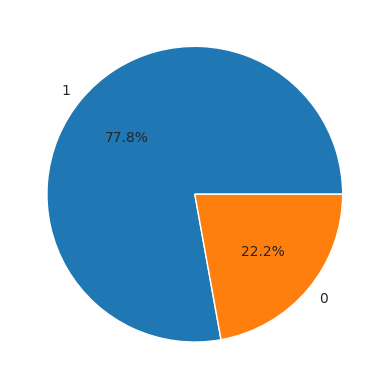

In [ ]:
statistics = train['isAlive'].value_counts()
plt.pie(statistics.values, labels=statistics.index, autopct='%1.1f%%')
plt.show()

Выводы:
- У классов присутствует серьёзный дизбаланс - выживших персонажей почти 78%, то есть их примерно в 3.5 раза больше, чем мёртвых

### Визуализация признаков на тренировочной выборке относительно целевой переменной

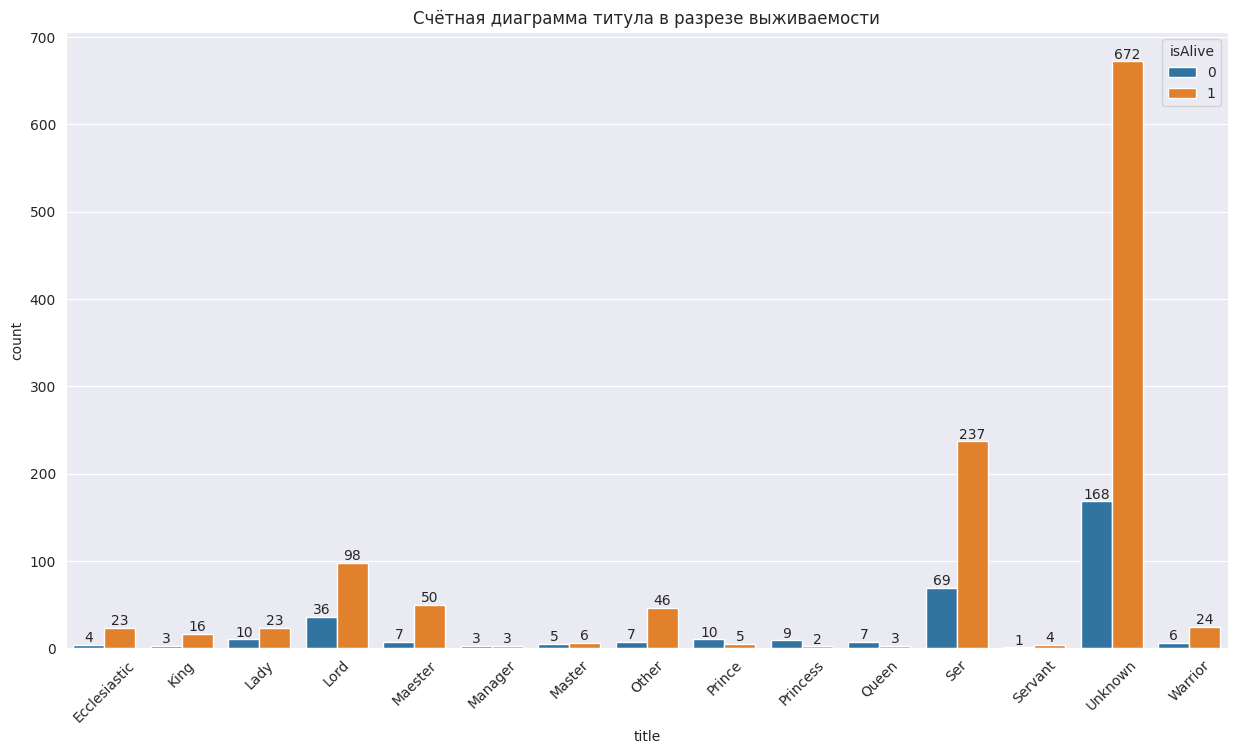

In [ ]:
_, ax = plt.subplots(figsize=(15, 8))
sorted_categories = sorted(train['title'].unique())
sns.countplot(data=train, x='title', hue='isAlive', order=sorted_categories, ax=ax)
for i in range(2):
    ax.bar_label(ax.containers[i])
plt.xticks(rotation=45)
plt.title('Счётная диаграмма титула в разрезе выживаемости')
plt.show()

Выводы:
- Почти во всех категориях за исключением принцев, принцесс и королев умерших было меньше, чем выживших
- У священнослужителей, королей, леди, лордов, магистров, сэров, войнов, а также у тех, чьи титулы входут в группу "Остальное" или неизвестны, живых более чем в 2 раза больше, чем мёртвых
- У управлящих и магистров примерное равенство в вопросе выживаемости


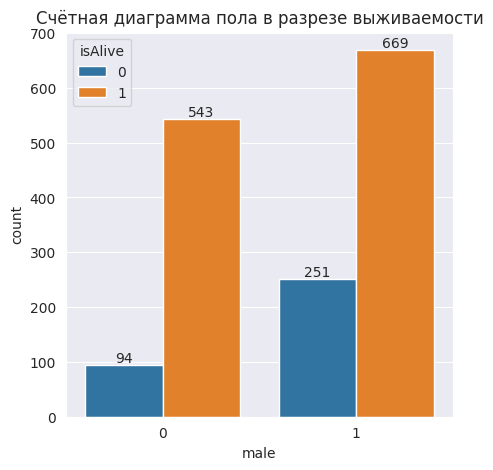

In [ ]:
_, ax = plt.subplots(figsize=(5, 5))
sorted_categories = sorted(train['male'].unique())
sns.countplot(data=train, x='male', hue='isAlive', order=sorted_categories, ax=ax)
for i in range(2):
    ax.bar_label(ax.containers[i])
plt.title('Счётная диаграмма пола в разрезе выживаемости')
plt.show()

Выводы:
- Мужских персонажей больше, чем женских
- Выживших мужчин больше, чем выживших женщин, а также мёртвых мужчин больше, чем мёртвых женщин

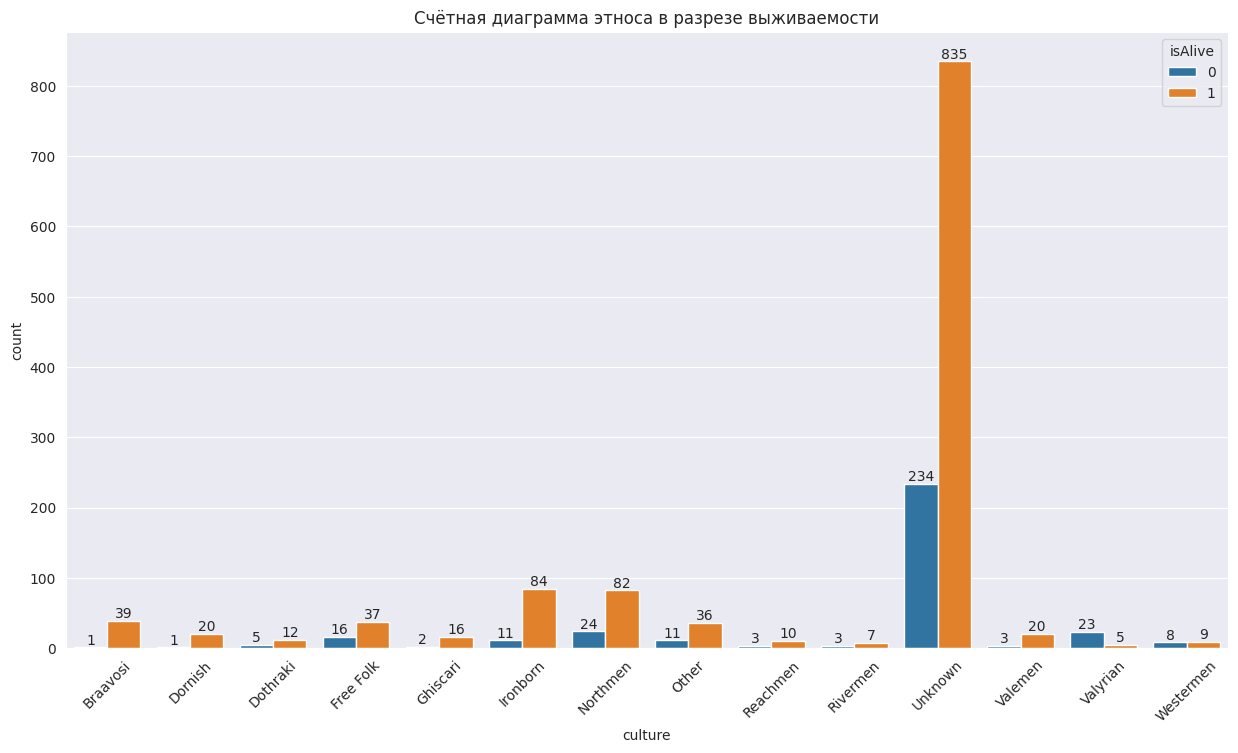

In [ ]:
_, ax = plt.subplots(figsize=(15, 8))
sorted_categories = sorted(train['culture'].unique())
sns.countplot(data=train, x='culture', hue='isAlive', order=sorted_categories, ax=ax)
for i in range(2):
    ax.bar_label(ax.containers[i])
plt.xticks(rotation=45)
plt.title('Счётная диаграмма этноса в разрезе выживаемости')
plt.show()

Выводы:
- У всех этносов за исключением Valyrian и Westermen количество выживших более чем 2 раза превышает количество умерших
- Vayrian - единственный народ, у которого количество умерших преавышает количество выживших, причём более чем в 4.5 раза
- Braavosi и Dornish демонстрируют уникальную выживаемость

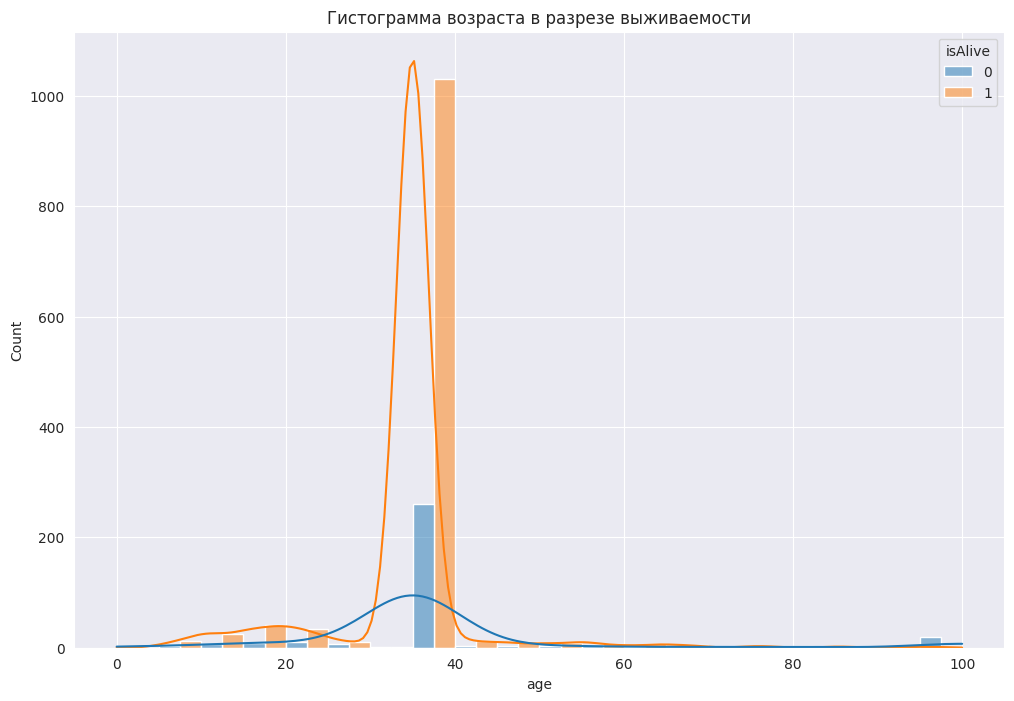

In [ ]:
_, ax = plt.subplots(figsize=(12, 8))
sns.histplot(data=train, x='age', hue='isAlive', multiple='dodge', kde=True, bins=20, ax=ax)
plt.title('Гистограмма возраста в разрезе выживаемости')
plt.show()

Выводы:
- У обоих гистограмм видим пик в районе 35 лет - это среднее всех неотсутствующих значений, именно средним были закодированы отсутствующие значения возраста, коих записей было большинство, так что ничего удивительного тут нет
- До совсем уж больших значений (около 100 лет) количество живых превышает количество мёртвых

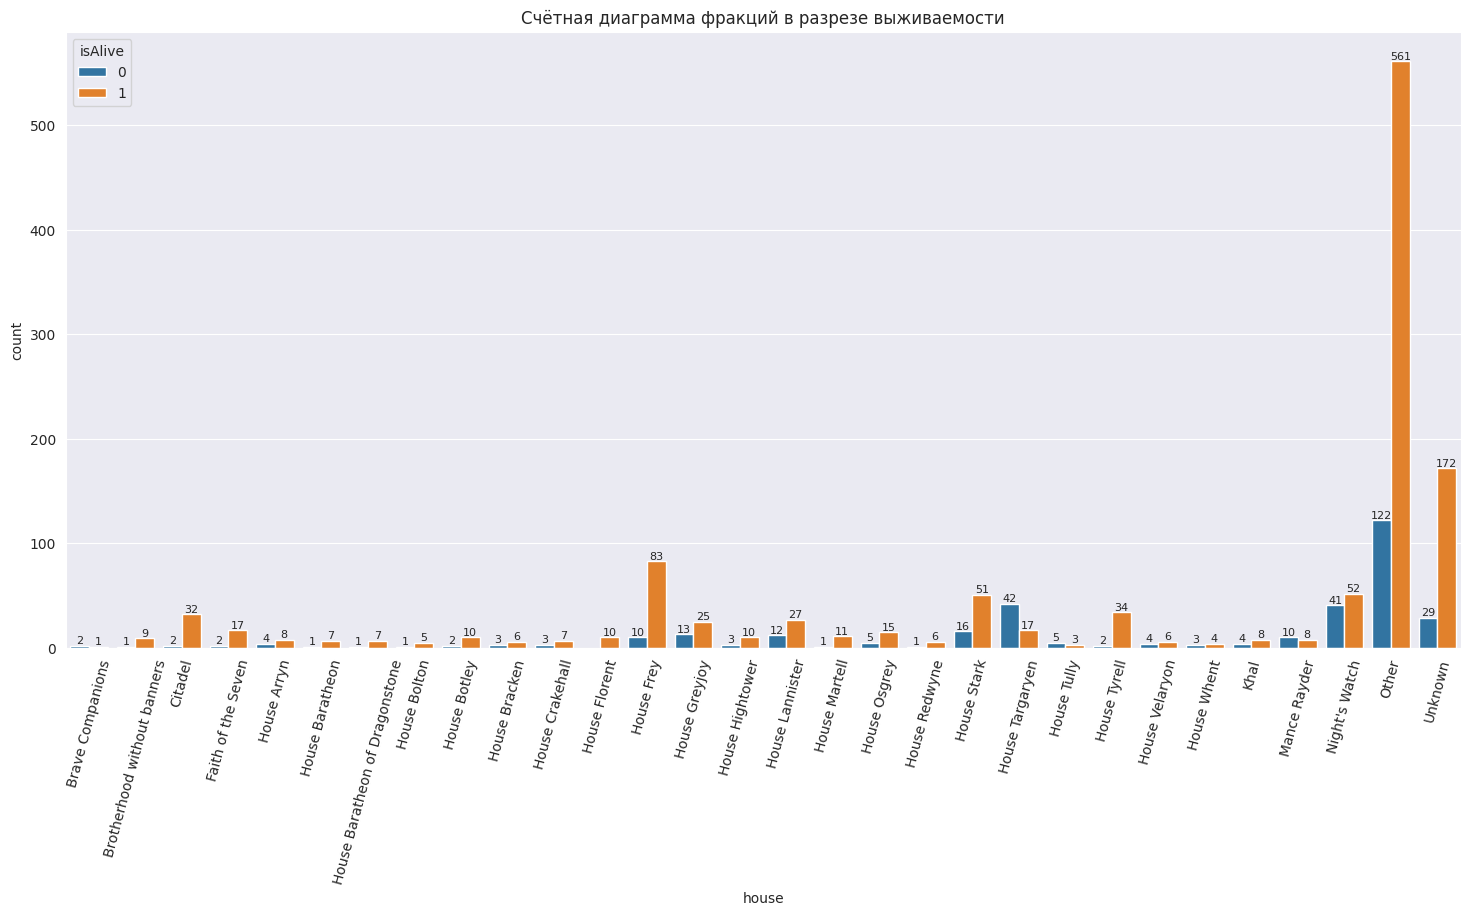

In [ ]:
_, ax = plt.subplots(figsize=(18, 8))
sorted_categories = sorted(train['house'].unique())
sns.countplot(data=train, x='house', hue='isAlive', order=sorted_categories, ax=ax)
for i in range(2):
    ax.bar_label(ax.containers[i], fontsize=8)
plt.xticks(rotation=75)
plt.title('Счётная диаграмма фракций в разрезе выживаемости')
plt.show()

Выврды:
- В основном у фракций количество выживших больше, чем мёртвых
- Исключение в предыдущем пункте принадлежит либо фракции Ночного Дозора, либо дому Таргариенов
- У дома Флорента выжили все

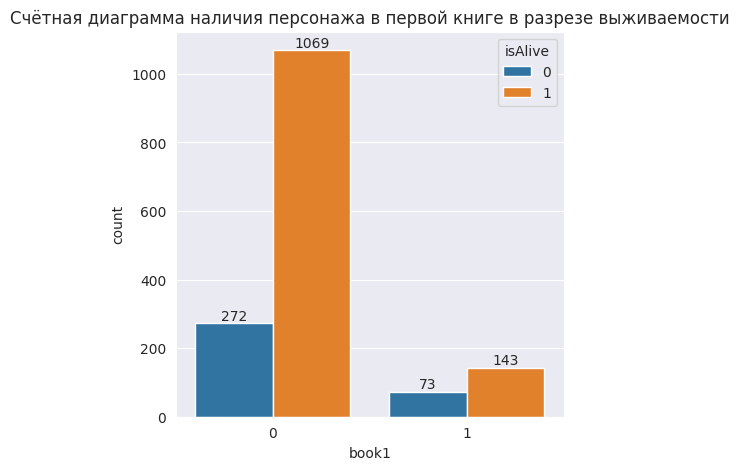

In [ ]:
_, ax = plt.subplots(figsize=(5, 5))
sorted_categories = sorted(train['book1'].unique())
sns.countplot(data=train, x='book1', hue='isAlive', order=sorted_categories, ax=ax)
for i in range(2):
    ax.bar_label(ax.containers[i])
plt.title('Счётная диаграмма наличия персонажа в первой книге в разрезе выживаемости')
plt.show()

Выводы:
- Значительное большинство персонажей не появлялось в первой книге
- Внушительное большинство из заявленных в книге персонажей выжило

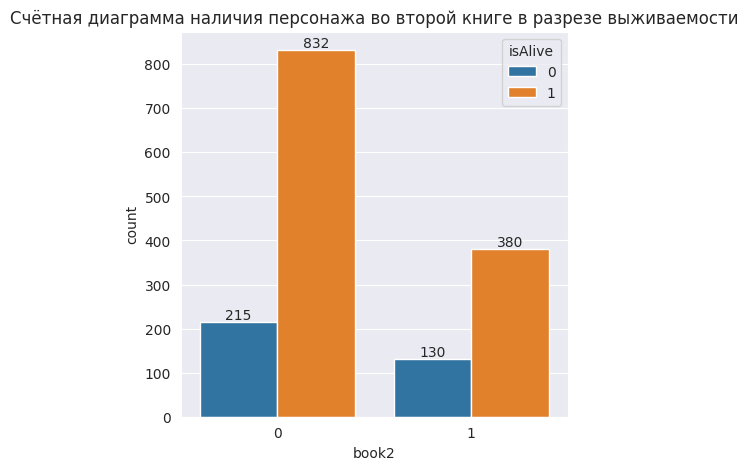

In [ ]:
_, ax = plt.subplots(figsize=(5, 5))
sorted_categories = sorted(train['book2'].unique())
sns.countplot(data=train, x='book2', hue='isAlive', order=sorted_categories, ax=ax)
for i in range(2):
    ax.bar_label(ax.containers[i])
plt.title('Счётная диаграмма наличия персонажа во второй книге в разрезе выживаемости')
plt.show()

Выводы:
- Также большинство персонажей не появлялось и во второй книге
- Во второй книге персонажей вышло меньше, чем в первой
- Здесь также большинство персонажей выжило

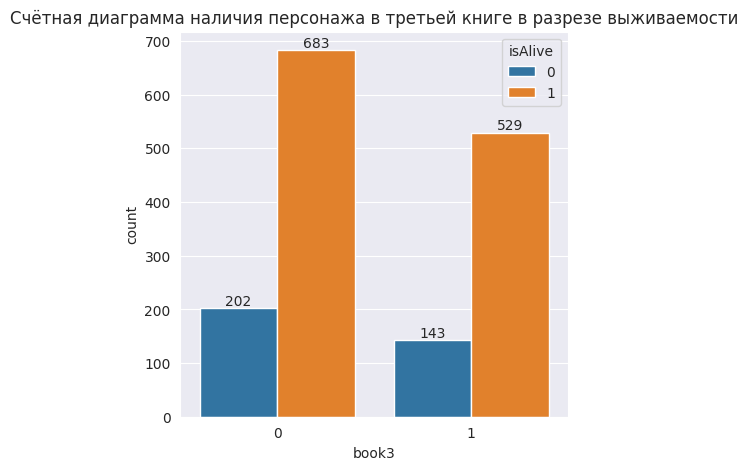

In [ ]:
_, ax = plt.subplots(figsize=(5, 5))
sorted_categories = sorted(train['book3'].unique())
sns.countplot(data=train, x='book3', hue='isAlive', order=sorted_categories, ax=ax)
for i in range(2):
    ax.bar_label(ax.containers[i])
plt.title('Счётная диаграмма наличия персонажа в третьей книге в разрезе выживаемости')
plt.show()

- Здесь по-прежнему большинство персонажей не повляется в книге, однако разница уже не так значима, как в предыдущих случаях
- Более чем 75% имеющихся в книге персонажей в итоге выжило
- То же относится и к отсутсвующим в книге персонажам

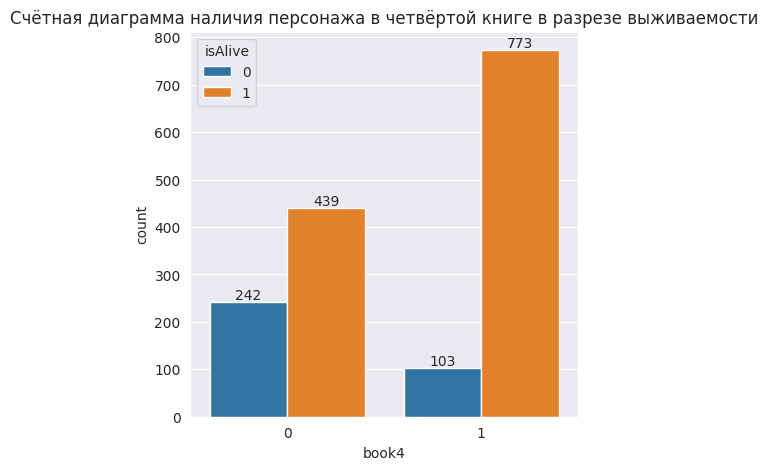

In [ ]:
_, ax = plt.subplots(figsize=(5, 5))
sorted_categories = sorted(train['book4'].unique())
sns.countplot(data=train, x='book4', hue='isAlive', order=sorted_categories, ax=ax)
for i in range(2):
    ax.bar_label(ax.containers[i])
plt.title('Счётная диаграмма наличия персонажа в четвёртой книге в разрезе выживаемости')
plt.show()

Выводы:
- Ситуация наконец переменилась - большинство персонажей присутствукет в книге
- Опять в обоих случаях большинство персонажей выживает

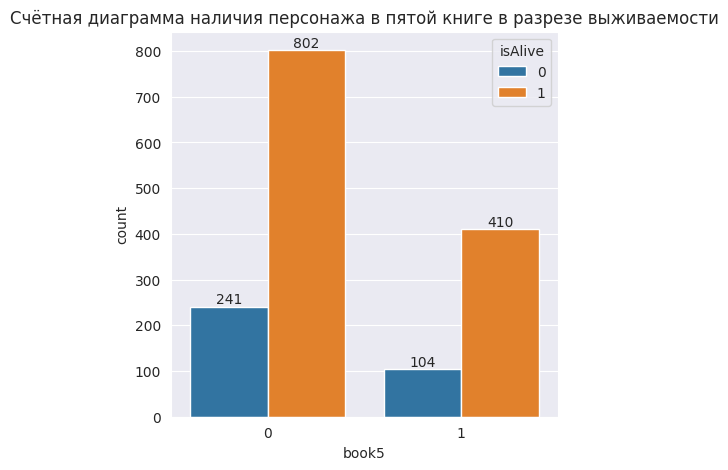

In [ ]:
_, ax = plt.subplots(figsize=(5, 5))
sorted_categories = sorted(train['book5'].unique())
sns.countplot(data=train, x='book5', hue='isAlive', order=sorted_categories, ax=ax)
for i in range(2):
    ax.bar_label(ax.containers[i])
plt.title('Счётная диаграмма наличия персонажа в пятой книге в разрезе выживаемости')
plt.show()

Выводы:
- Более всего ситуация аналогична той, что была в третьей книге

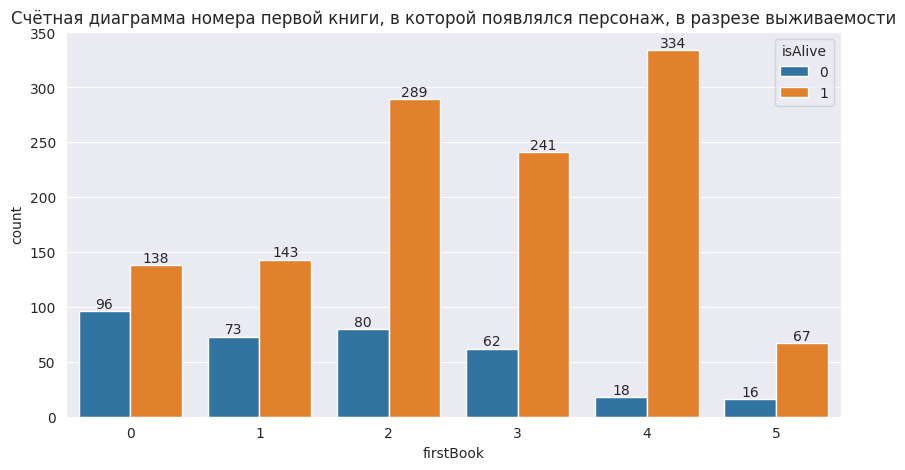

In [ ]:
_, ax = plt.subplots(figsize=(10, 5))
sorted_categories = sorted(train['firstBook'].unique())
sns.countplot(data=train, x='firstBook', hue='isAlive', order=sorted_categories, ax=ax)
for i in range(2):
    ax.bar_label(ax.containers[i])
plt.title('Счётная диаграмма номера первой книги, в которой появлялся персонаж, в разрезе выживаемости')
plt.show()

Выводы:
- Для каждой книги верно, что персонажи, которые впервые появлялись в ней, чаще выживали, чем умирали
- Самая маленькая разница у тех, кто впервые появляется в нулевой книге, то есть по сути, не появляется ни в одной из 5 книг
- Самое большое количество новых персонажей появилось в третьей книге
- Самое большое количество новых выживших персонажей было в четвёртой книге

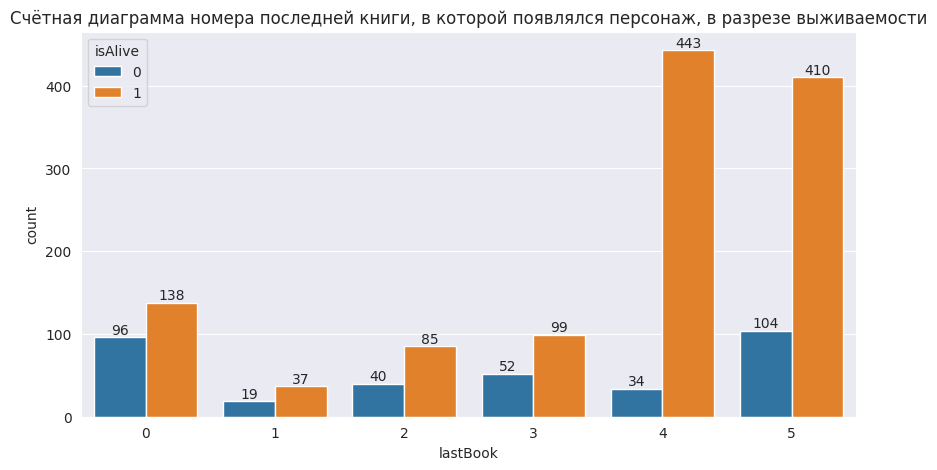

In [ ]:
_, ax = plt.subplots(figsize=(10, 5))
sorted_categories = sorted(train['lastBook'].unique())
sns.countplot(data=train, x='lastBook', hue='isAlive', order=sorted_categories, ax=ax)
for i in range(2):
    ax.bar_label(ax.containers[i])
plt.title('Счётная диаграмма номера последней книги, в которой появлялся персонаж, в разрезе выживаемости')
plt.show()

Выводы:
- Для каждой книги верно, что персонажи, которые в последний раз появлялись в ней, чаще выживали, чем умирали
- Самая маленькая разница у тех, кто в последний раз появился в первой книге
- Самое большое количество персонажей появилось в последний раз в четвёртой книге
- Самое большое количество умерших персонажей появилось в последний раз в пятой книге

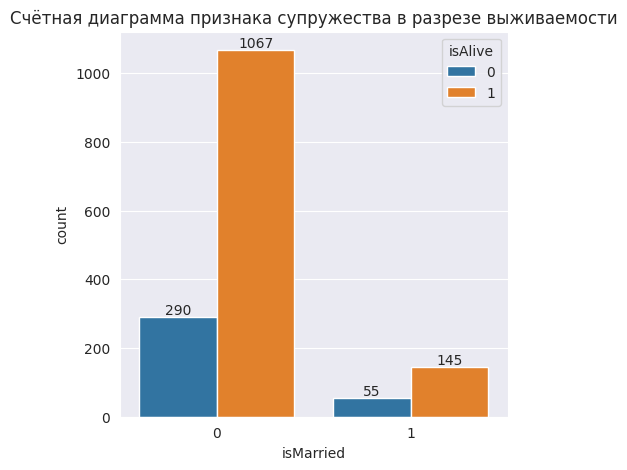

In [ ]:
_, ax = plt.subplots(figsize=(5, 5))
sorted_categories = sorted(train['isMarried'].unique())
sns.countplot(data=train, x='isMarried', hue='isAlive', order=sorted_categories, ax=ax)
for i in range(2):
    ax.bar_label(ax.containers[i])
plt.title('Счётная диаграмма признака супружества в разрезе выживаемости')
plt.show()

Выводы:
- Большинство персонажей неженаты
- В обоих категориях количесто выживших превалирует над количество умерших

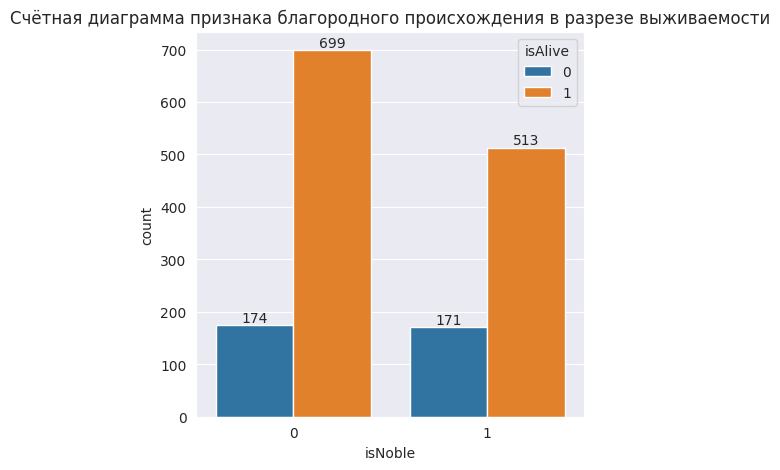

In [ ]:
_, ax = plt.subplots(figsize=(5, 5))
sorted_categories = sorted(train['isNoble'].unique())
sns.countplot(data=train, x='isNoble', hue='isAlive', order=sorted_categories, ax=ax)
for i in range(2):
    ax.bar_label(ax.containers[i])
plt.title('Счётная диаграмма признака благородного происхождения в разрезе выживаемости')
plt.show()

Выводы:
- Большинство персонажей не имеют благородного происхождения
- В обоих категориях количесто выживших превалирует над количество умерших
- Количество умерших в обоих категориях примерно равно

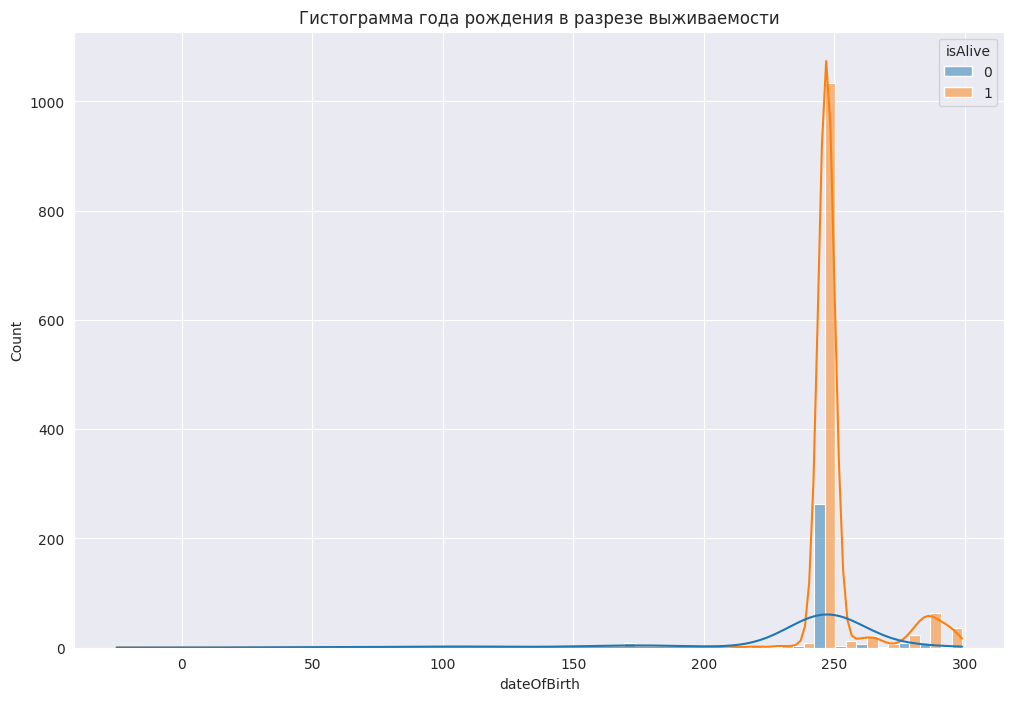

In [ ]:
_, ax = plt.subplots(figsize=(12, 8))
sns.histplot(data=train, x='dateOfBirth', hue='isAlive', multiple='dodge', kde=True, bins=40, ax=ax)
plt.title('Гистограмма года рождения в разрезе выживаемости')
plt.show()

Выводы:
- Все года рождения персонажей в основном превышают 230
- Видим пики у обоих распределений в районе 250 - это среднее всех возрастов, которым кодировались отсутсвующие значения
- Количество умерших для кадого бина меньше количества живых

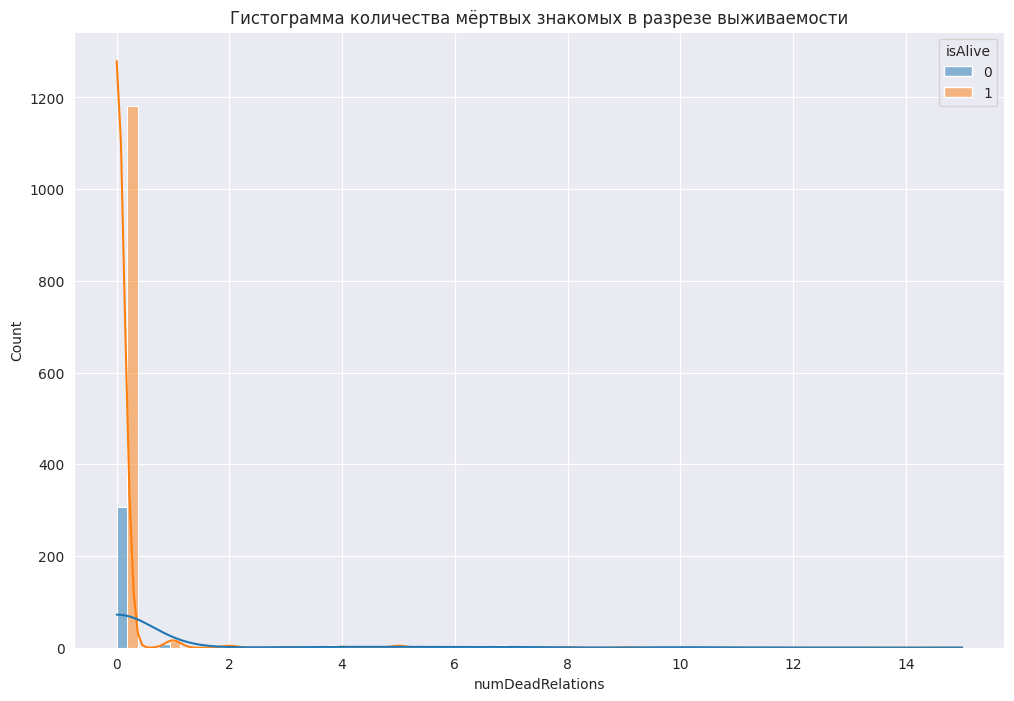

In [ ]:
_, ax = plt.subplots(figsize=(12, 8))
sns.histplot(data=train, x='numDeadRelations', hue='isAlive', multiple='dodge', kde=True, bins=40, ax=ax)
plt.title('Гистограмма количества мёртвых знакомых в разрезе выживаемости')
plt.show()

Выводы:
- Большинство персонажей имеют 0 мёртвых знакомых
- Оставшееся меньшинство в большинстве своём имеет 1 мёртвого знакомого
- Опять для каждого бина количество живых больше количества мёртвых

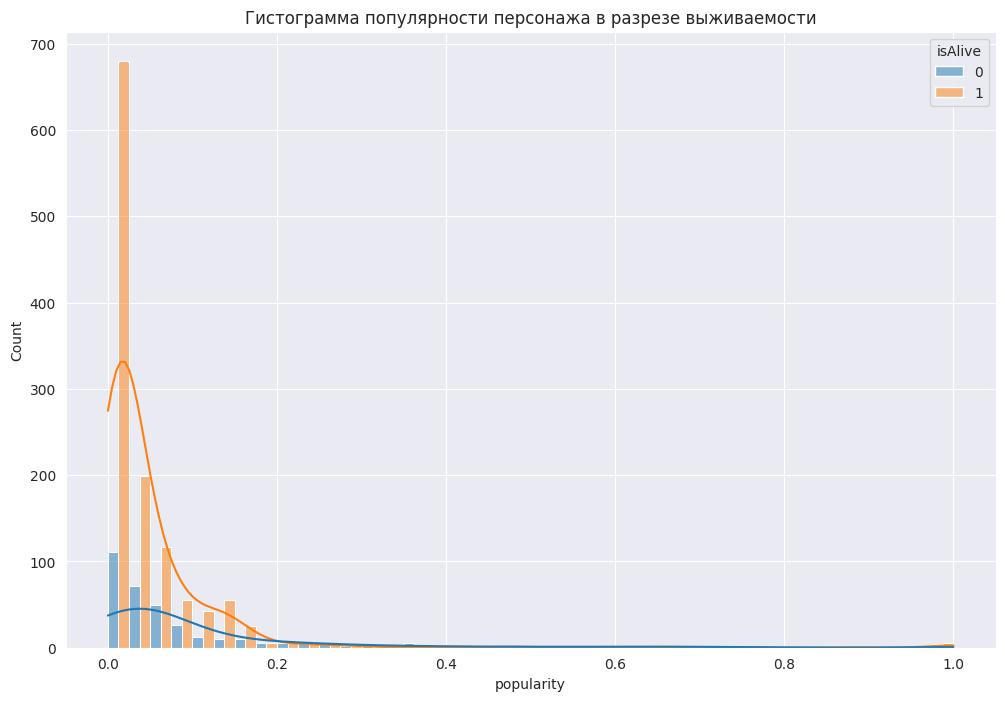

In [ ]:
_, ax = plt.subplots(figsize=(12, 8))
sns.histplot(data=train, x='popularity', hue='isAlive', multiple='dodge', kde=True, bins=40, ax=ax)
plt.title('Гистограмма популярности персонажа в разрезе выживаемости')
plt.show()

Выводы:
- Популярность для обоих случаев в осовном идёт на убыль
- Для каждого бина количество выживших больше количества умерших

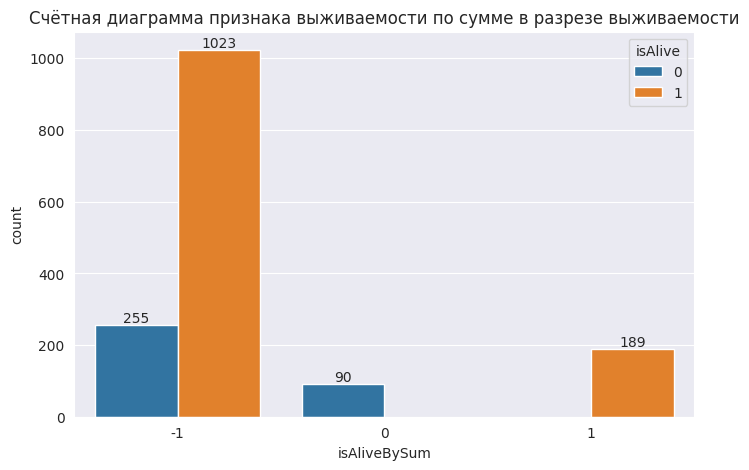

In [ ]:
_, ax = plt.subplots(figsize=(8, 5))
sorted_categories = sorted(train['isAliveBySum'].unique())
sns.countplot(data=train, x='isAliveBySum', hue='isAlive', order=sorted_categories, ax=ax)
for i in range(2):
    ax.bar_label(ax.containers[i])
plt.title('Счётная диаграмма признака выживаемости по сумме в разрезе выживаемости')
plt.show()

Выводы:
- Помним, что для нулевых и единичных значений выживаемость определяется однозначно
- Для тех объектов, где возраст и год рождения неизвестны, выживших персонажей в 4 раза больше, чем умерших

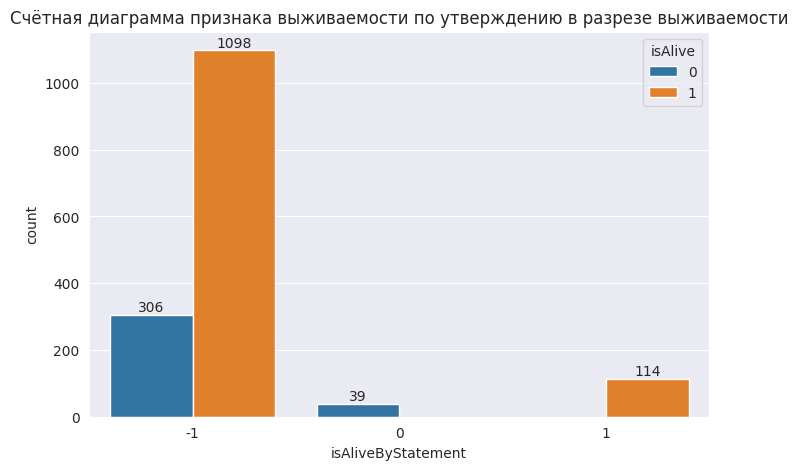

In [ ]:
_, ax = plt.subplots(figsize=(8, 5))
sorted_categories = sorted(train['isAliveByStatement'].unique())
sns.countplot(data=train, x='isAliveByStatement', hue='isAlive', order=sorted_categories, ax=ax)
for i in range(2):
    ax.bar_label(ax.containers[i])
plt.title('Счётная диаграмма признака выживаемости по утверждению в разрезе выживаемости')
plt.show()

Выводы:
- Помним, что для нулевых и единичных значений выживаемость определяется однозначно
- Для тех объектов, где возраст и год рождения неизвестны, выживших персонажей примерно в 3 раза больше, чем умерших

### Сравнение распределений на тренировочной и тестовой выборках

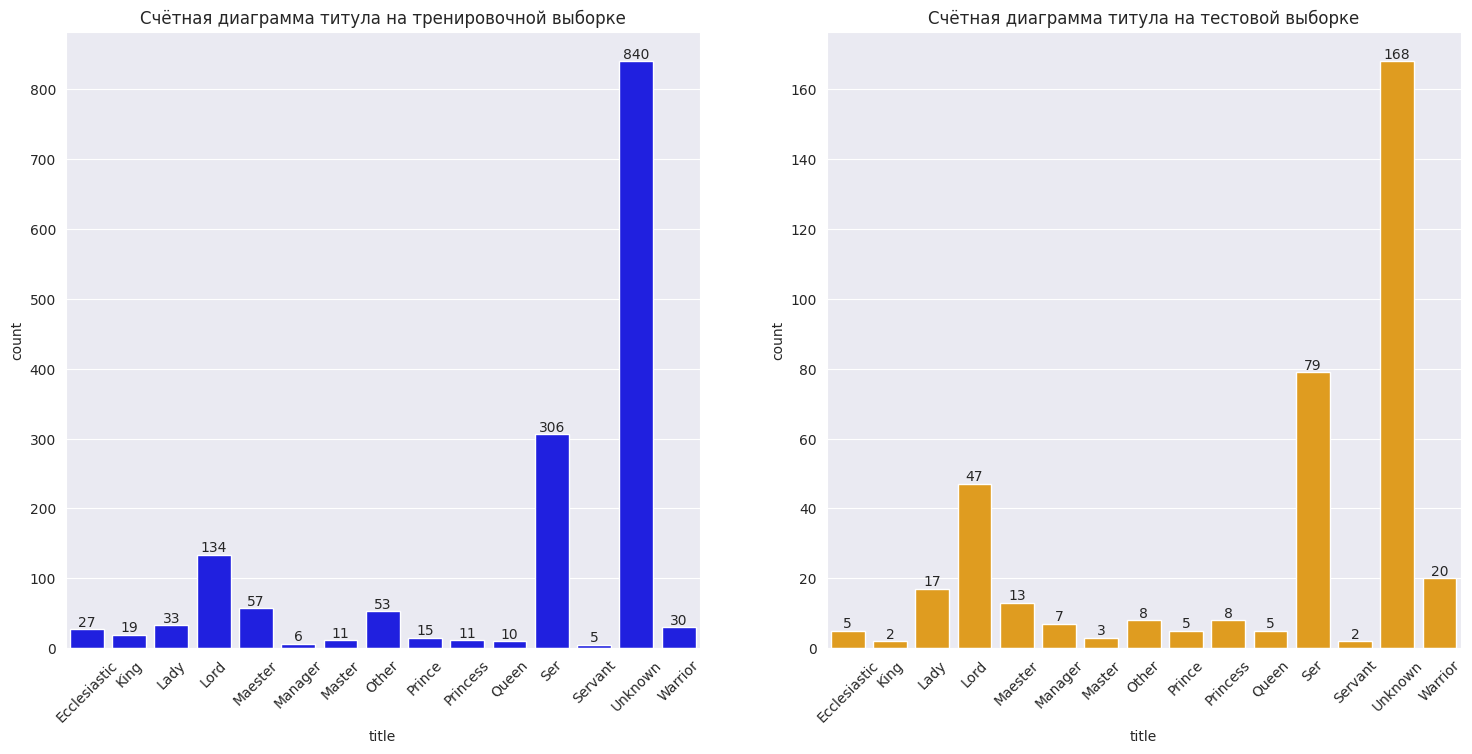

In [ ]:
_, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 8))
sorted_categories = sorted(train['title'].unique())
sns.countplot(data=train, x='title', order=sorted_categories, ax=axes[0], color='blue')
sns.countplot(data=test, x='title', order=sorted_categories, ax=axes[1], color='orange')
for i in range(2):
    axes[i].bar_label(axes[i].containers[0])
for axis in axes.flat:
    axis.tick_params(axis='x', rotation=45)
axes[0].set_title('Счётная диаграмма титула на тренировочной выборке')
axes[1].set_title('Счётная диаграмма титула на тестовой выборке')
plt.show()

Выводы:
- В целом, распределения похожи, но есть некоторые различия
- Некоторые категории, например Warrior, Lord, Lady, на тестовой выборке имеют бОльшие значения, чем должны были бы
- А другие категории, например King, Other, наоборот, имеют меньшие значения, чем следовало бы

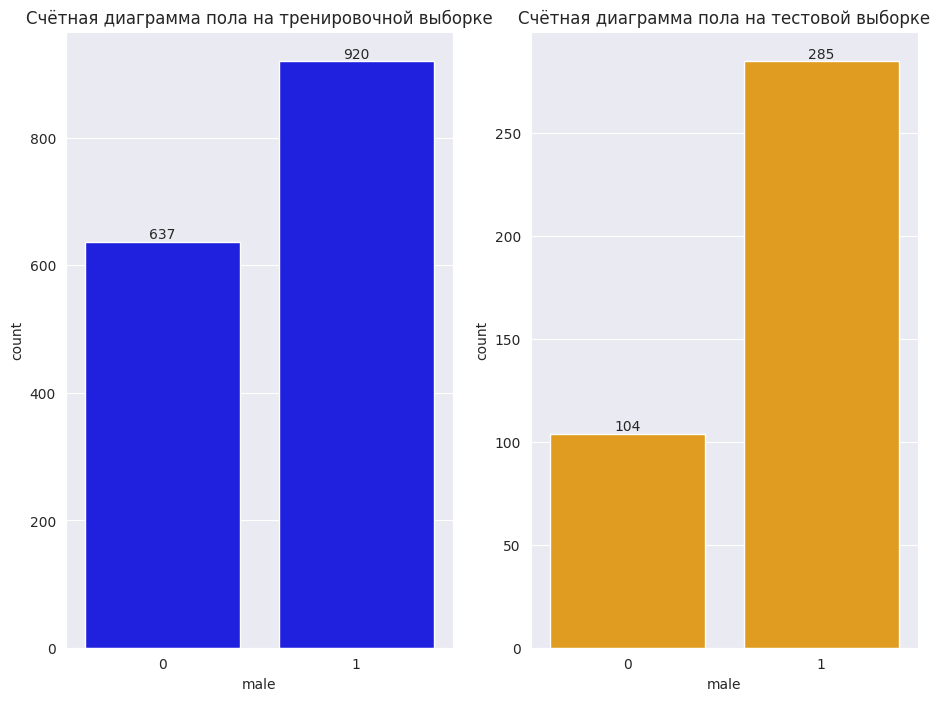

In [ ]:
_, axes = plt.subplots(nrows=1, ncols=2, figsize=(11, 8))
sorted_categories = sorted(train['male'].unique())
sns.countplot(data=train, x='male', order=sorted_categories, ax=axes[0], color='blue')
sns.countplot(data=test, x='male', order=sorted_categories, ax=axes[1], color='orange')
for i in range(2):
    axes[i].bar_label(axes[i].containers[0])
axes[0].set_title('Счётная диаграмма пола на тренировочной выборке')
axes[1].set_title('Счётная диаграмма пола на тестовой выборке')
plt.show()

Выводы:
- На тренировочной выборке разница между выжившими и умершими в процентном соотношении меньше, чем на тестовой

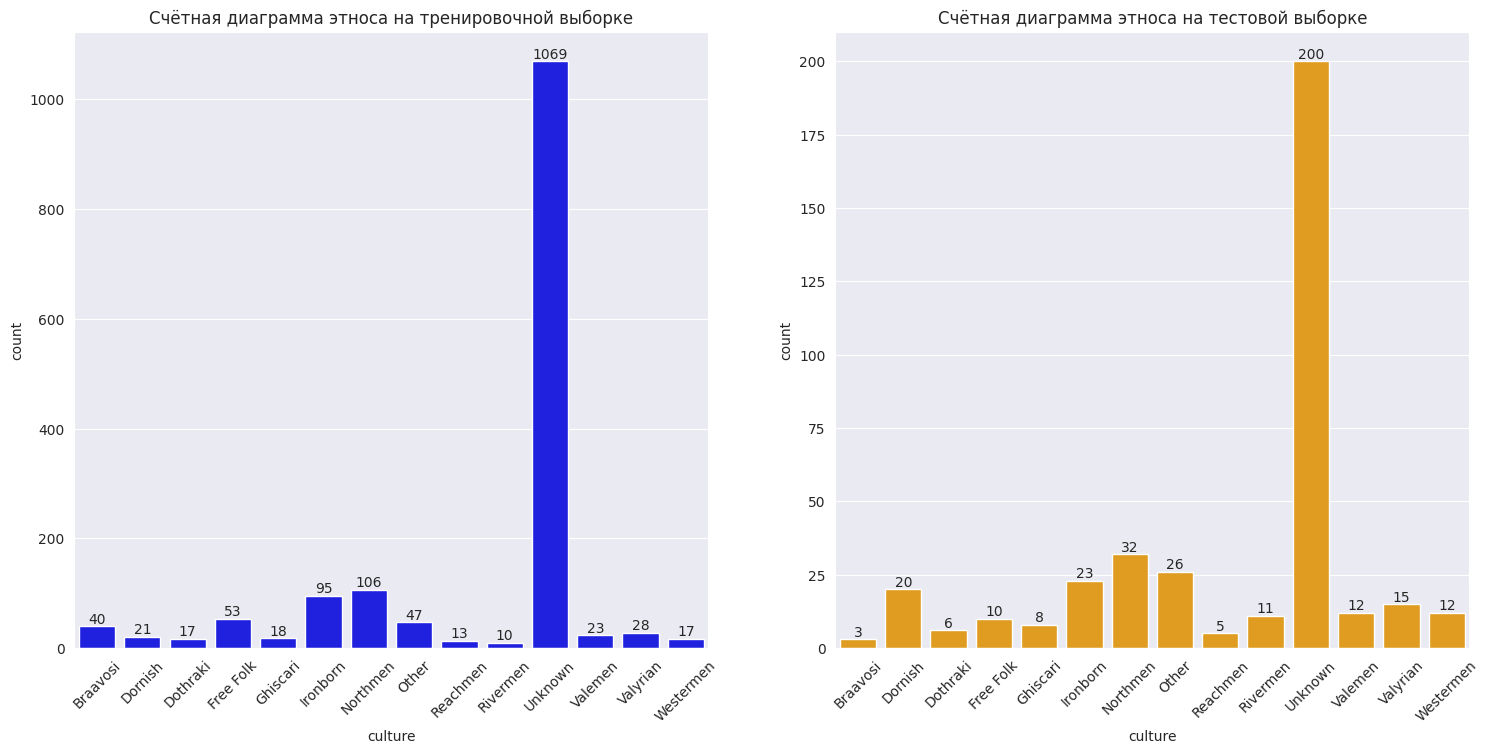

In [ ]:
_, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 8))
sorted_categories = sorted(train['culture'].unique())
sns.countplot(data=train, x='culture', order=sorted_categories, ax=axes[0], color='blue')
sns.countplot(data=test, x='culture', order=sorted_categories, ax=axes[1], color='orange')
for i in range(2):
    axes[i].bar_label(axes[i].containers[0])
for axis in axes.flat:
    axis.tick_params(axis='x', rotation=45)
axes[0].set_title('Счётная диаграмма этноса на тренировочной выборке')
axes[1].set_title('Счётная диаграмма этноса на тестовой выборке')
plt.show()

Выводы:
- Ситуация схожа с признакв титула - распределения похожи друг на друга, но на тестовой выборке одни бины должны быть выше, а другие ниже

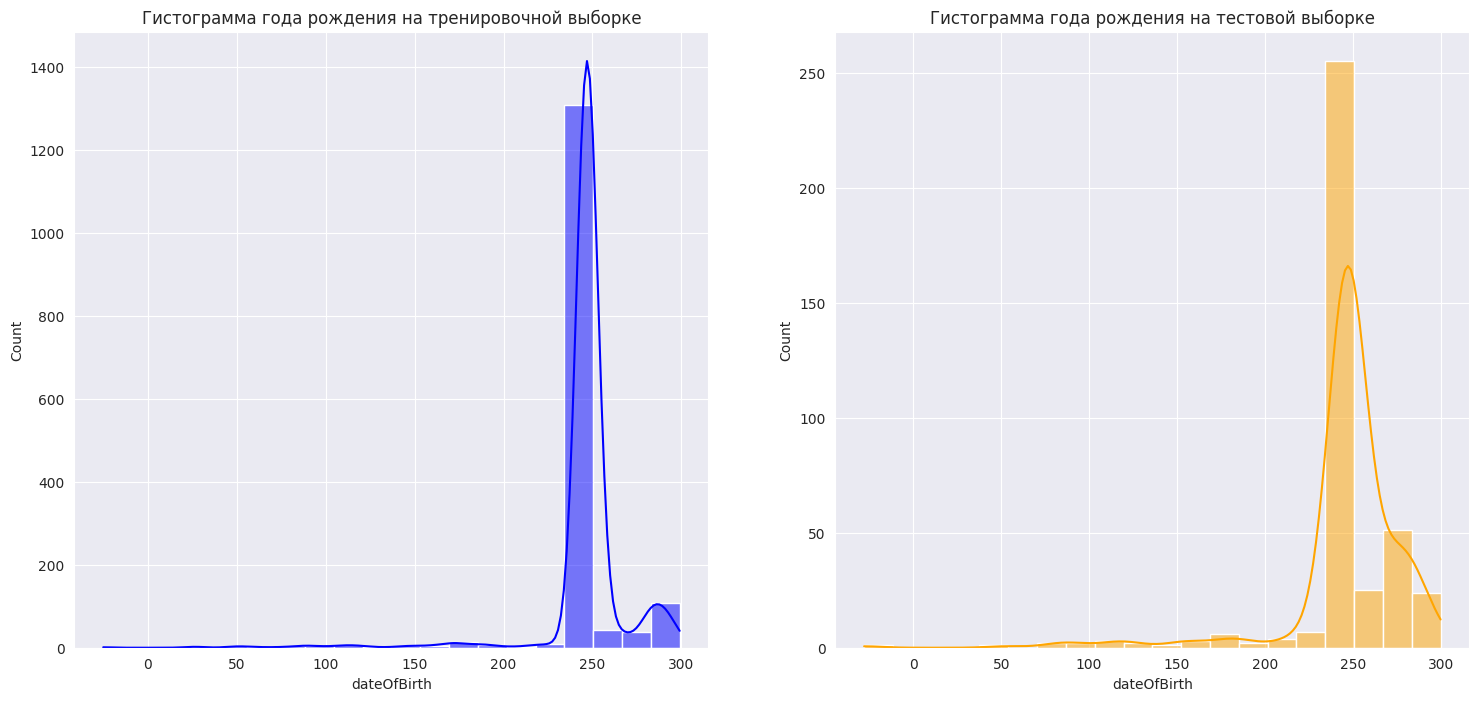

In [ ]:
_, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 8))
sns.histplot(data=train, x='dateOfBirth', kde=True, bins=20, ax=axes[0], color='blue')
sns.histplot(data=test, x='dateOfBirth', kde=True, bins=20, ax=axes[1], color='orange')
axes[0].set_title('Гистограмма года рождения на тренировочной выборке')
axes[1].set_title('Гистограмма года рождения на тестовой выборке')
plt.show()

Выводы:
- Пики распределений - это среднее всех возрастов, которым кодировались пропуски
- На тренировочной выборке справа у расределения пик в период с 283 по 300 годы, тогда как на тестовой - с 267 по 283
- В целом, в тестовой выборке присутствует больше персонажей, чьи года рождения меньше 200, чем в тренировочной

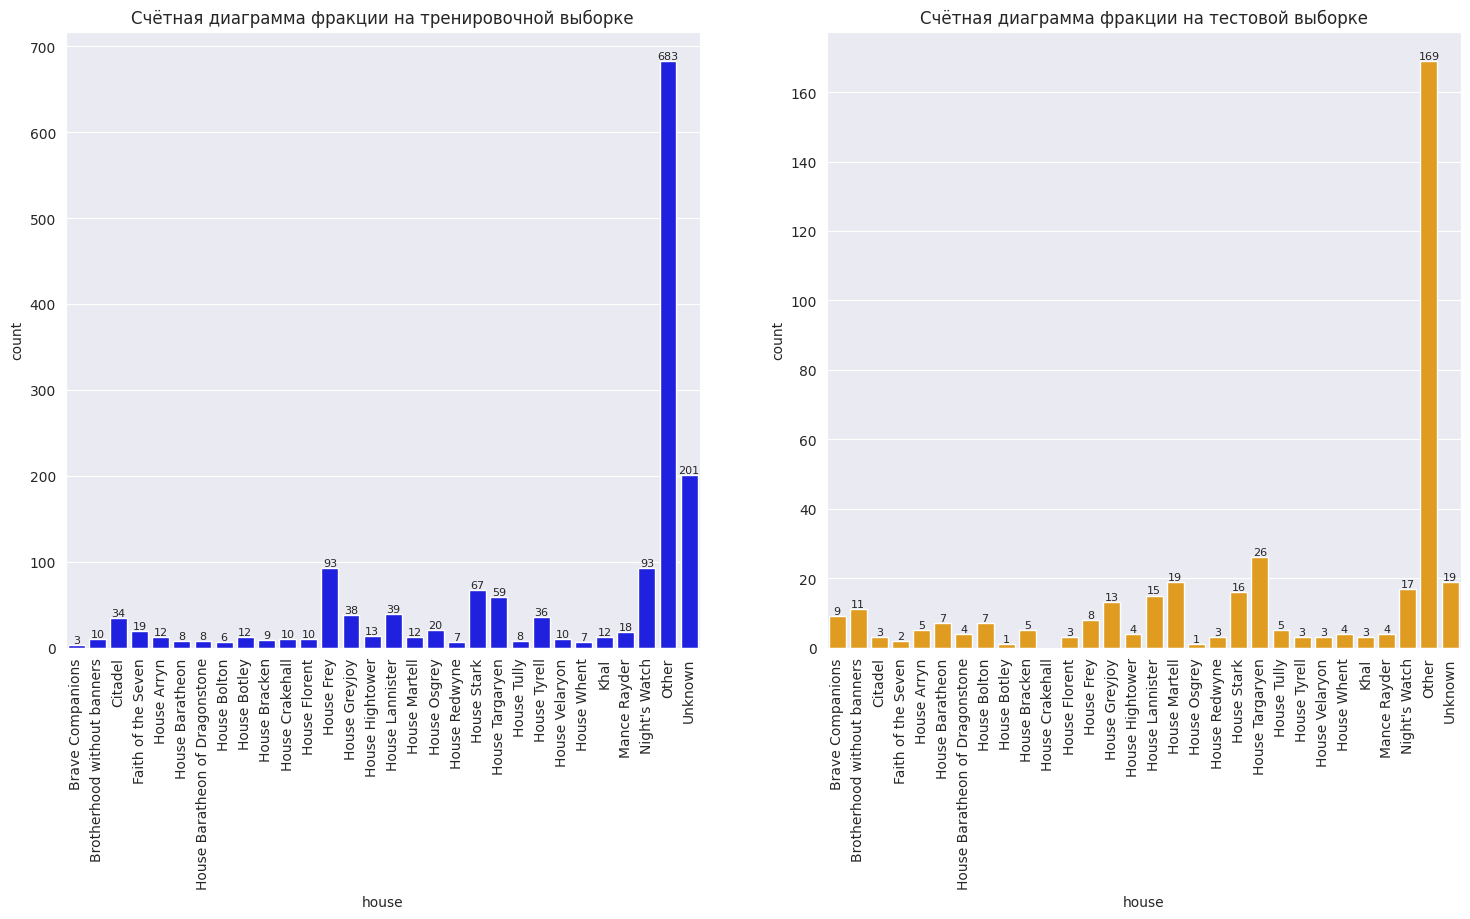

In [ ]:
_, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 8))
sorted_categories = sorted(train['house'].unique())
sns.countplot(data=train, x='house', order=sorted_categories, ax=axes[0], color='blue')
sns.countplot(data=test, x='house', order=sorted_categories, ax=axes[1], color='orange')
for i in range(2):
    axes[i].bar_label(axes[i].containers[0], fontsize=8)
for axis in axes.flat:
    axis.tick_params(axis='x', rotation=90)
axes[0].set_title('Счётная диаграмма фракции на тренировочной выборке')
axes[1].set_title('Счётная диаграмма фракции на тестовой выборке')
plt.show()

Выводы:
- Непохожесть этих 2 распределений по сравнению с остальными признаками явно бросается в глаза (пики в разных местах, непропорциональность высот одних и тех же бинах в 2 выборках)

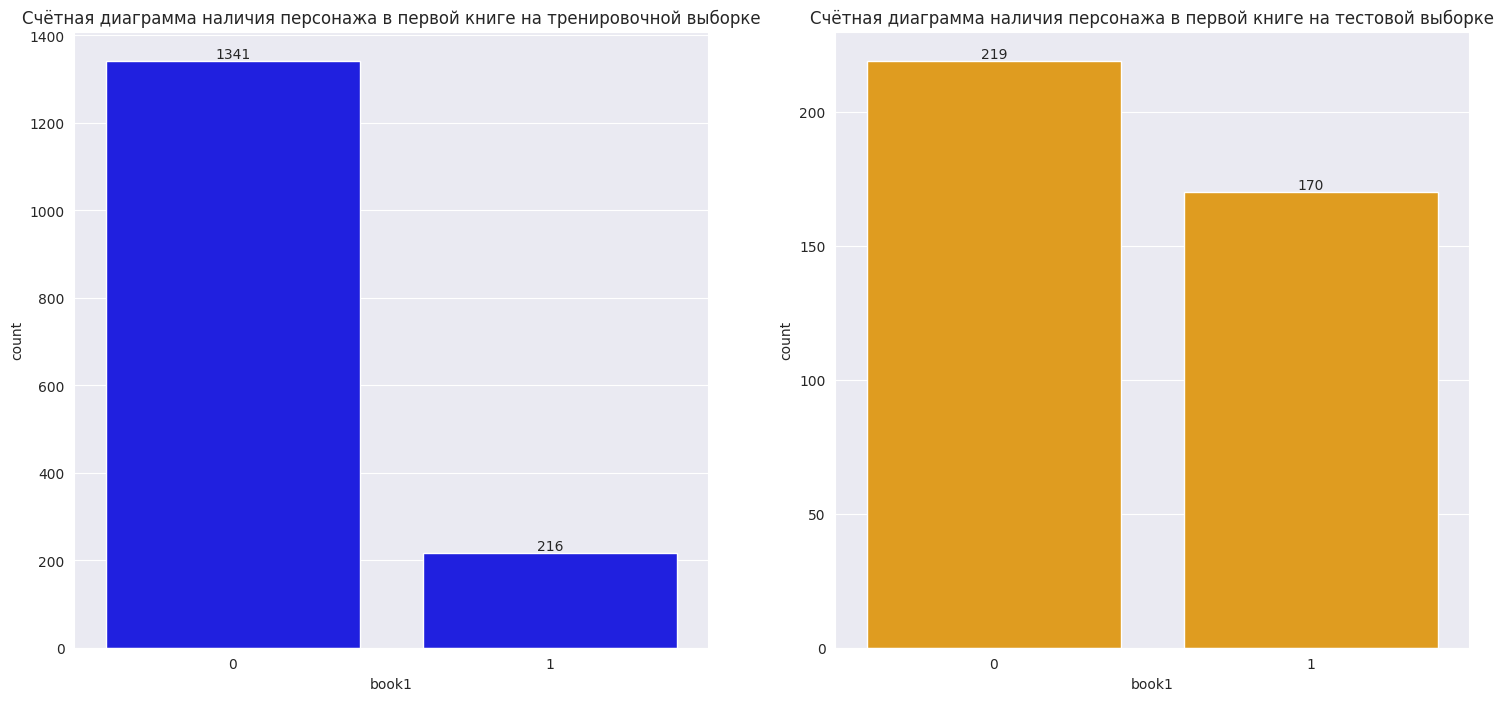

In [ ]:
_, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 8))
sorted_categories = sorted(train['book1'].unique())
sns.countplot(data=train, x='book1', order=sorted_categories, ax=axes[0], color='blue')
sns.countplot(data=test, x='book1', order=sorted_categories, ax=axes[1], color='orange')
for i in range(2):
    axes[i].bar_label(axes[i].containers[0])
axes[0].set_title('Счётная диаграмма наличия персонажа в первой книге на тренировочной выборке')
axes[1].set_title('Счётная диаграмма наличия персонажа в первой книге на тестовой выборке')
plt.show()

Выводы:
- Видим здесь громадную разницу между разницами в процентном соотношении между живыми и умершими, на тренировочной выборке это (1341 / 216 ~ 6.2 и 219 / 170 ~ 1.29)
- Для обоих категорий вено, что большинство персонажей в первой книге не появляется

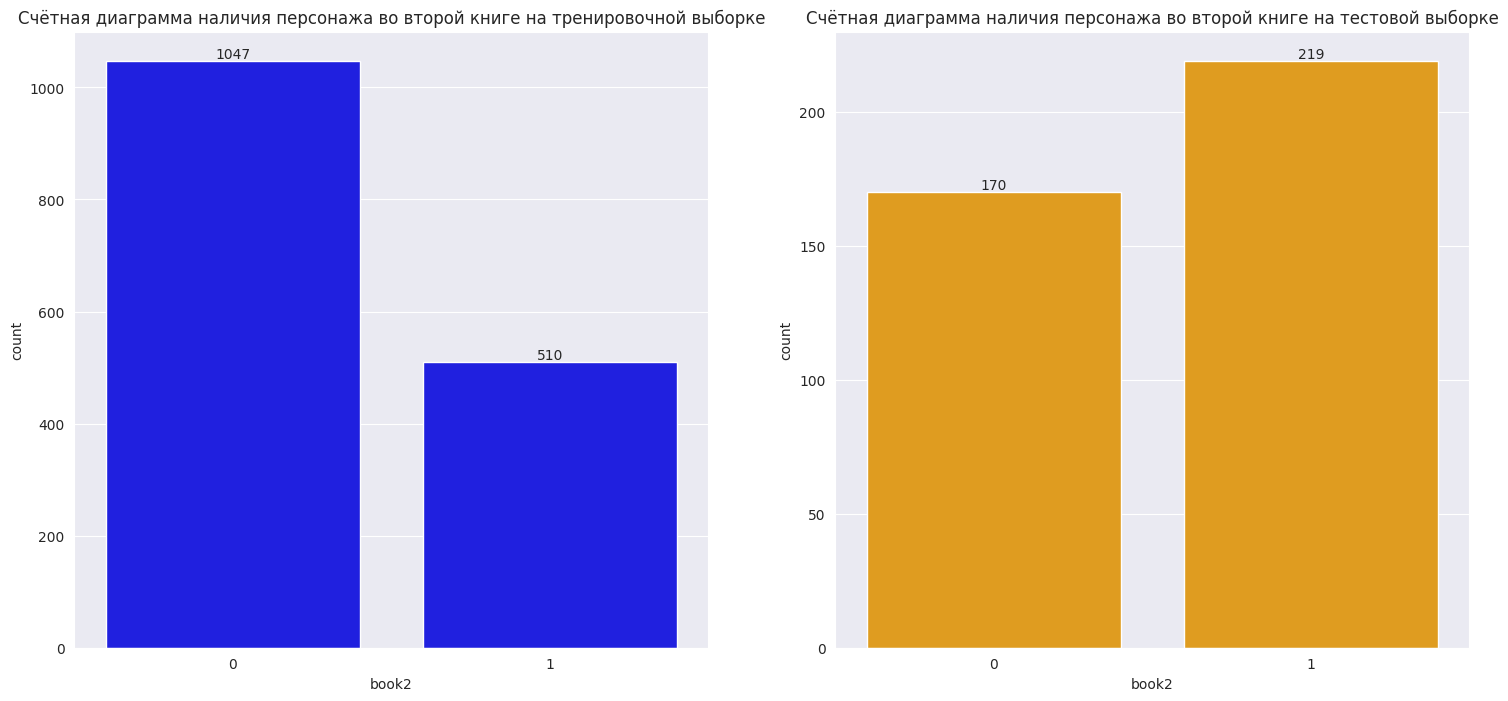

In [ ]:
_, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 8))
sorted_categories = sorted(train['book2'].unique())
sns.countplot(data=train, x='book2', order=sorted_categories, ax=axes[0], color='blue')
sns.countplot(data=test, x='book2', order=sorted_categories, ax=axes[1], color='orange')
for i in range(2):
    axes[i].bar_label(axes[i].containers[0])
axes[0].set_title('Счётная диаграмма наличия персонажа во второй книге на тренировочной выборке')
axes[1].set_title('Счётная диаграмма наличия персонажа во второй книге на тестовой выборке')
plt.show()

Выводы:
- Здесь для тестовой выборки большинство персонажей появляется во второй книге, а в тренировочной наоборот (если модель будет считать book2 важным признаком, то при предсказании на тестовой выборке многим объектам она может присвоить противоположный класс)

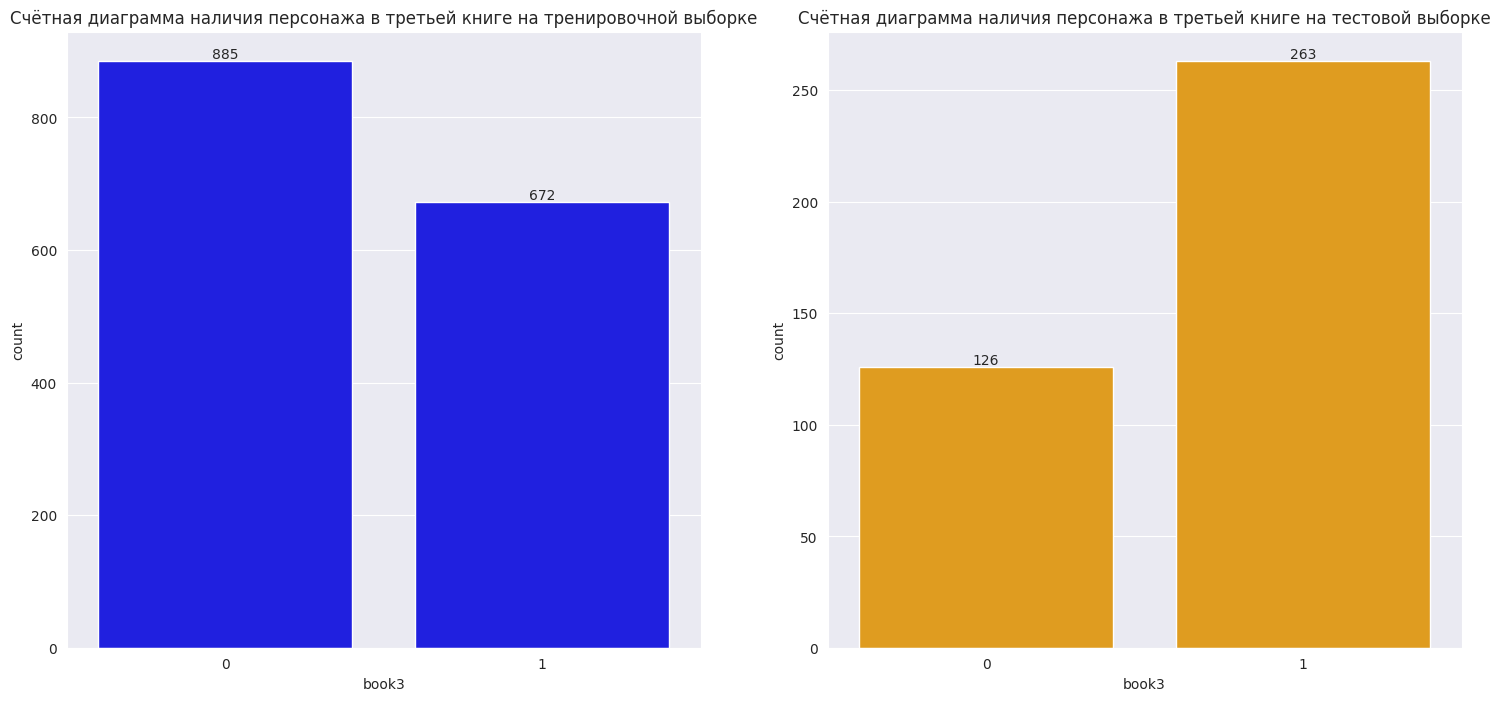

In [ ]:
_, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 8))
sorted_categories = sorted(train['book3'].unique())
sns.countplot(data=train, x='book3', order=sorted_categories, ax=axes[0], color='blue')
sns.countplot(data=test, x='book3', order=sorted_categories, ax=axes[1], color='orange')
for i in range(2):
    axes[i].bar_label(axes[i].containers[0])
axes[0].set_title('Счётная диаграмма наличия персонажа в третьей книге на тренировочной выборке')
axes[1].set_title('Счётная диаграмма наличия персонажа в третьей книге на тестовой выборке')
plt.show()

Выводы:
- Картина похожа на ту, что была с признаком book2, только в процентноми соотношении отношении [1] к [0]  на тестовой выборке больше, а на тренировочной меньше

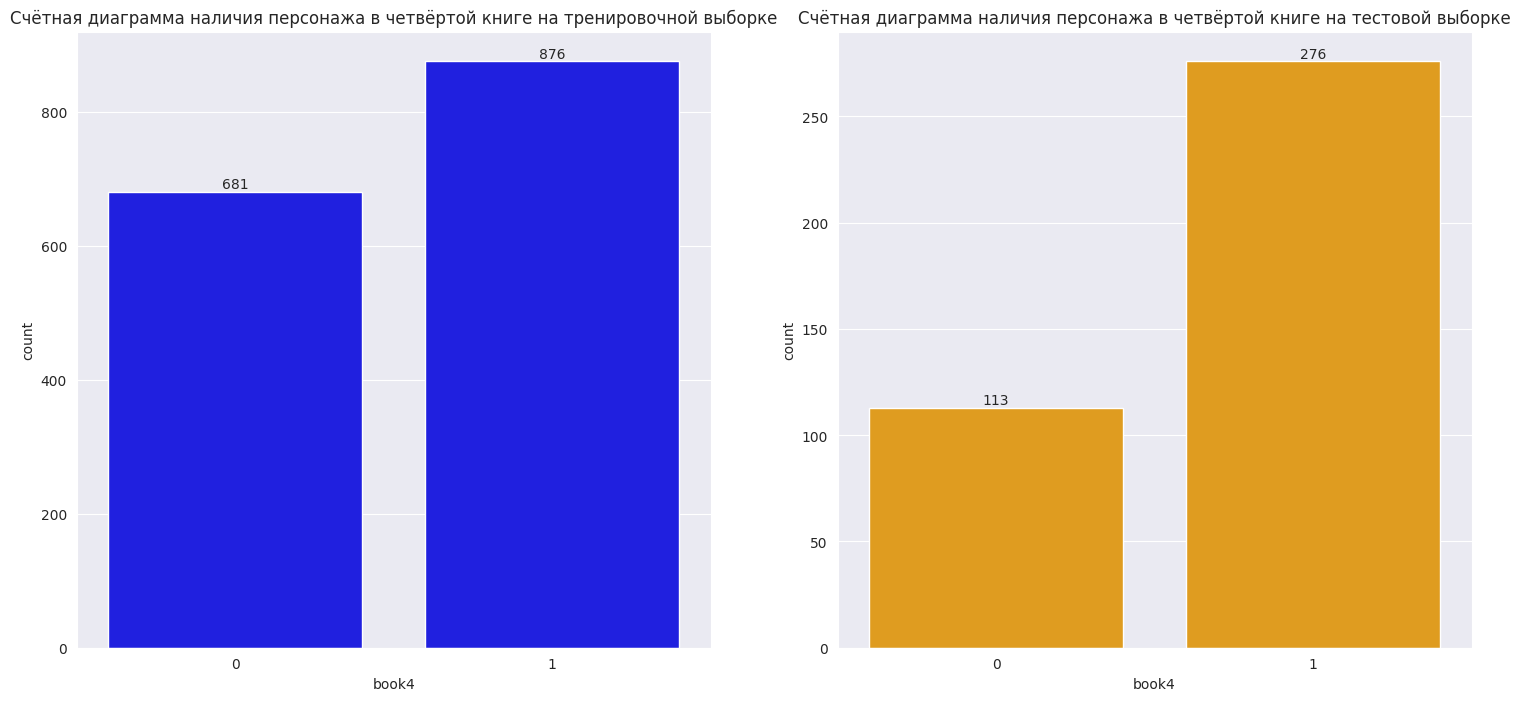

In [ ]:
_, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 8))
sorted_categories = sorted(train['book4'].unique())
sns.countplot(data=train, x='book4', order=sorted_categories, ax=axes[0], color='blue')
sns.countplot(data=test, x='book4', order=sorted_categories, ax=axes[1], color='orange')
for i in range(2):
    axes[i].bar_label(axes[i].containers[0])
axes[0].set_title('Счётная диаграмма наличия персонажа в четвёртой книге на тренировочной выборке')
axes[1].set_title('Счётная диаграмма наличия персонажа в четвёртой книге на тестовой выборке')
plt.show()

Выводы:
- Ситуация похожа на ту, чтт была с признаком book1, только теперь для обоих выборок большинство персонажей появляется в данной книге

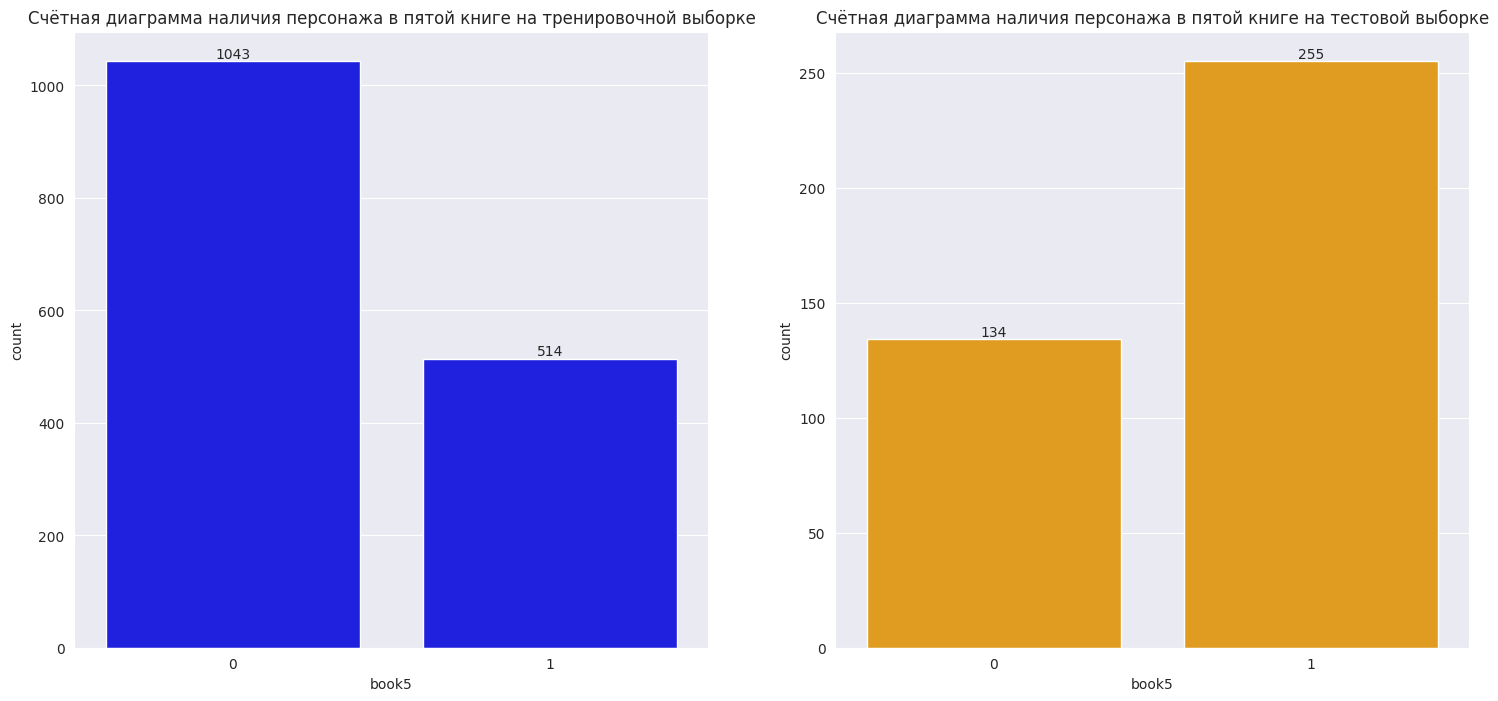

In [ ]:
_, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 8))
sorted_categories = sorted(train['book5'].unique())
sns.countplot(data=train, x='book5', order=sorted_categories, ax=axes[0], color='blue')
sns.countplot(data=test, x='book5', order=sorted_categories, ax=axes[1], color='orange')
for i in range(2):
    axes[i].bar_label(axes[i].containers[0])
axes[0].set_title('Счётная диаграмма наличия персонажа в пятой книге на тренировочной выборке')
axes[1].set_title('Счётная диаграмма наличия персонажа в пятой книге на тестовой выборке')
plt.show()

Выводы:
- Ситуация в целом напоминает ту, что была с признаком book2

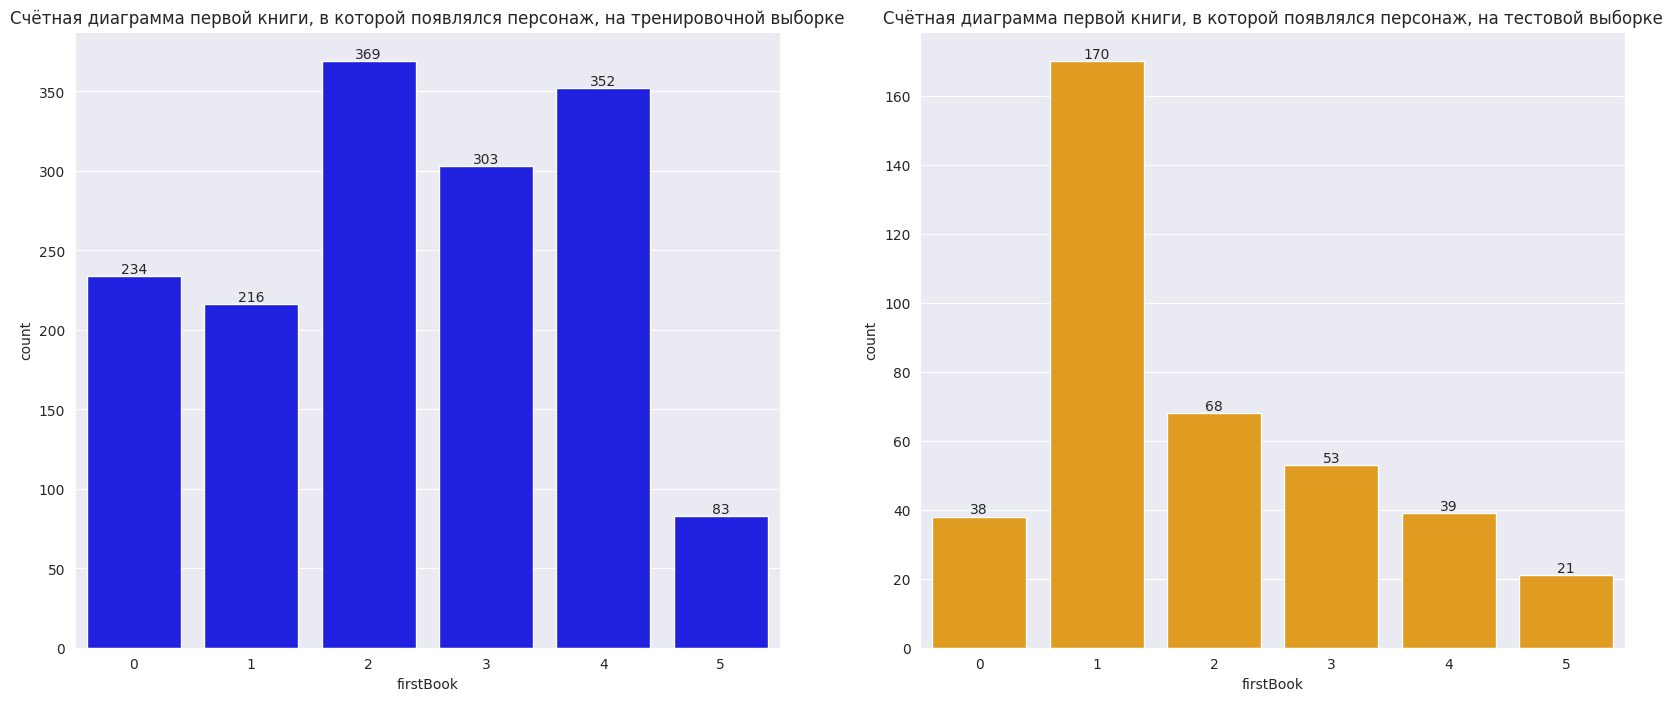

In [ ]:
_, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 8))
sorted_categories = sorted(train['firstBook'].unique())
sns.countplot(data=train, x='firstBook', order=sorted_categories, ax=axes[0], color='blue')
sns.countplot(data=test, x='firstBook', order=sorted_categories, ax=axes[1], color='orange')
for i in range(2):
    axes[i].bar_label(axes[i].containers[0])
axes[0].set_title('Счётная диаграмма первой книги, в которой появлялся персонаж, на тренировочной выборке')
axes[1].set_title('Счётная диаграмма первой книги, в которой появлялся персонаж, на тестовой выборке')
plt.show()

Выводы:
- Распределения совсем непохожи, возможно потомпридётся удалять этот признак

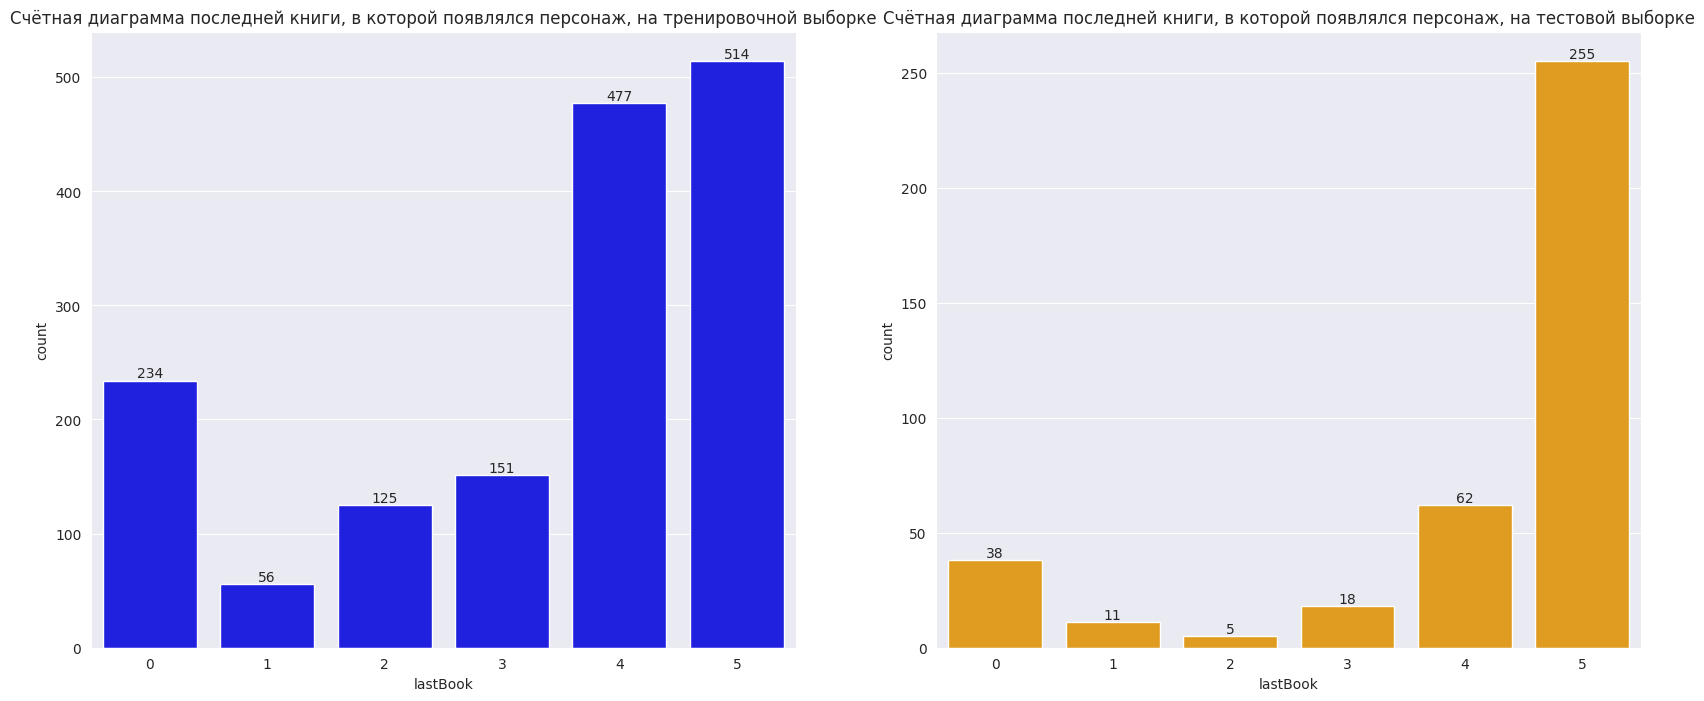

In [ ]:
_, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 8))
sorted_categories = sorted(train['lastBook'].unique())
sns.countplot(data=train, x='lastBook', order=sorted_categories, ax=axes[0], color='blue')
sns.countplot(data=test, x='lastBook', order=sorted_categories, ax=axes[1], color='orange')
for i in range(2):
    axes[i].bar_label(axes[i].containers[0])
axes[0].set_title('Счётная диаграмма последней книги, в которой появлялся персонаж, на тренировочной выборке')
axes[1].set_title('Счётная диаграмма последней книги, в которой появлялся персонаж, на тестовой выборке')
plt.show()

Выводы:
- Здесь, в целом, схожести больше, чем в предыдущем случае, однако и этот признак тоже под вопросом

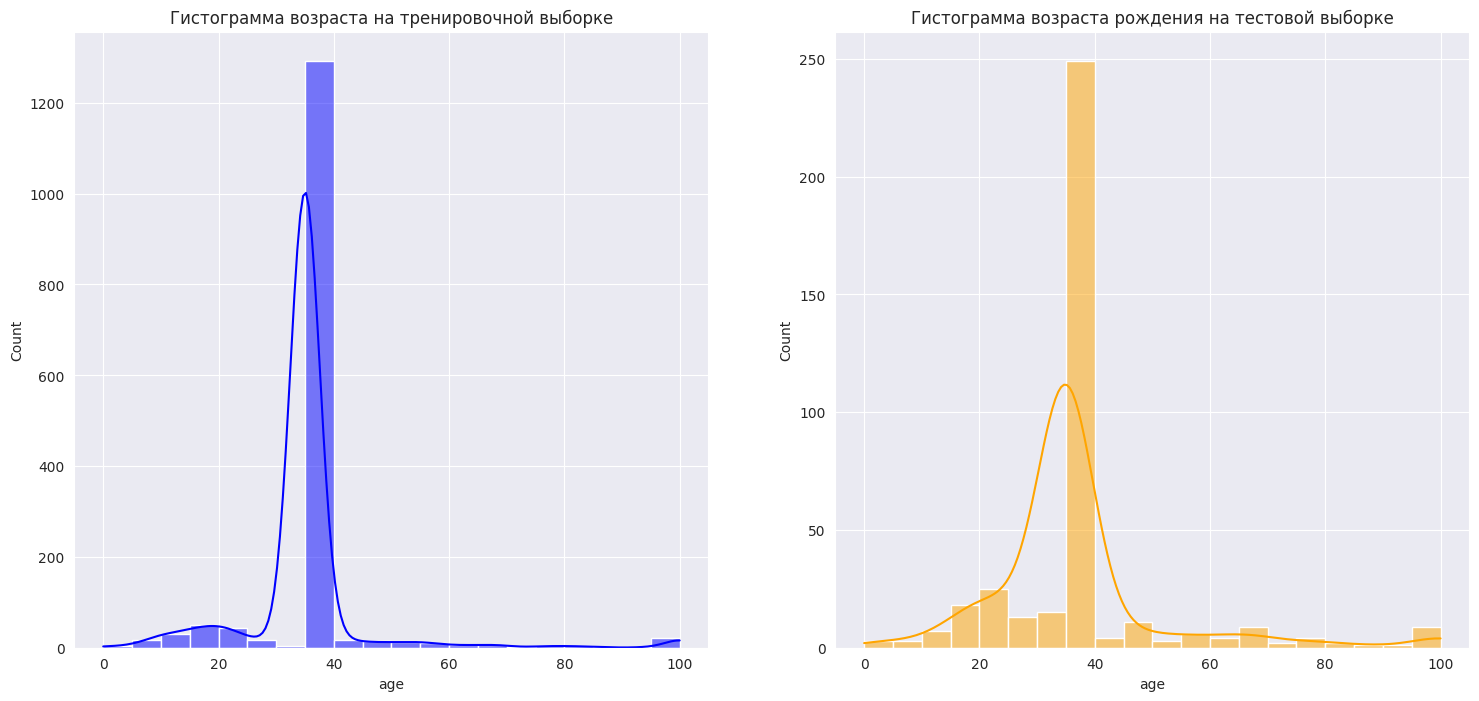

In [ ]:
_, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 8))
sns.histplot(data=train, x='age', kde=True, bins=20, ax=axes[0], color='blue')
sns.histplot(data=test, x='age', kde=True, bins=20, ax=axes[1], color='orange')
axes[0].set_title('Гистограмма возраста на тренировочной выборке')
axes[1].set_title('Гистограмма возраста рождения на тестовой выборке')
plt.show()

Выводы:
- Вы уже должны были выяснить, что означают пики
- Левые края распределений похожи, правые - не очень, у тестовой выбоорки более высокие бины, то есть в ней больше возрастных персонажей

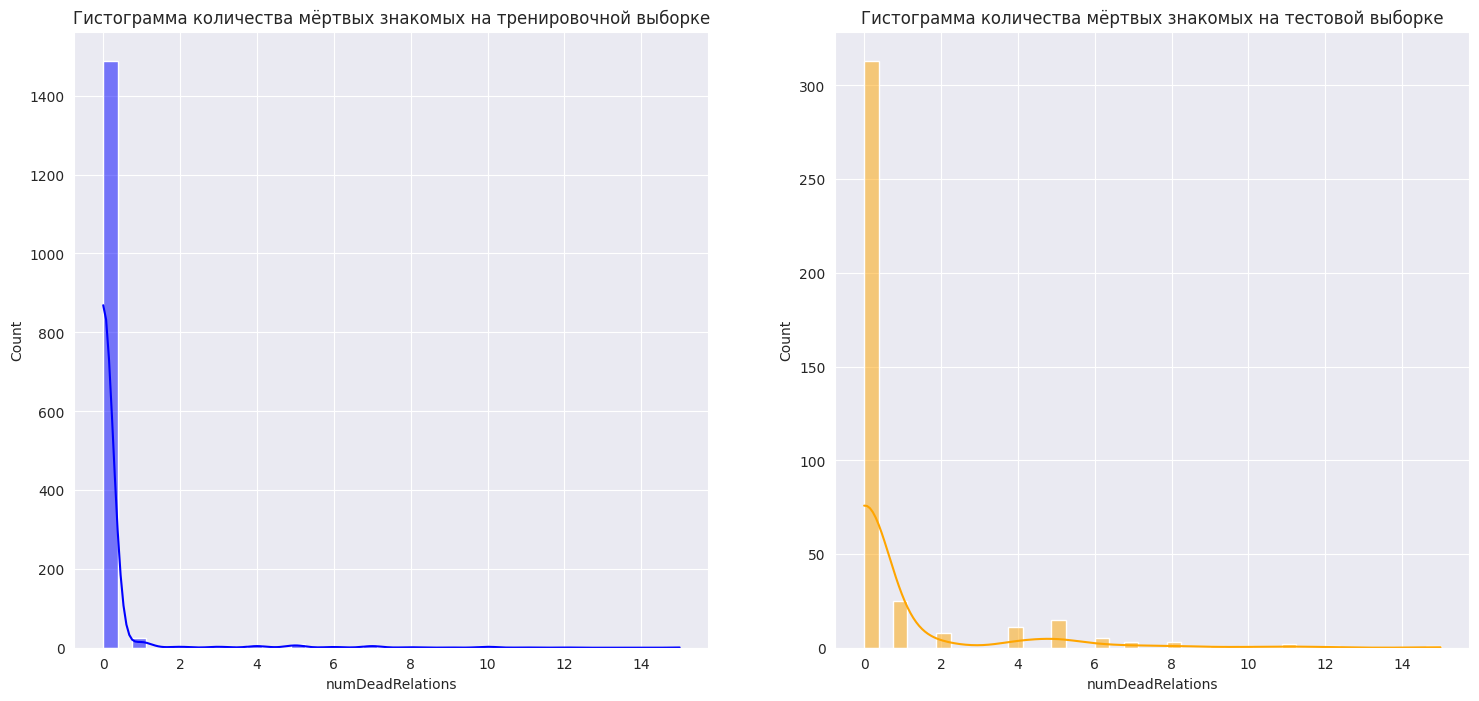

In [ ]:
_, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 8))
sns.histplot(data=train, x='numDeadRelations', kde=True, bins=40, ax=axes[0], color='blue')
sns.histplot(data=test, x='numDeadRelations', kde=True, bins=40, ax=axes[1], color='orange')
axes[0].set_title('Гистограмма количества мёртвых знакомых на тренировочной выборке')
axes[1].set_title('Гистограмма количества мёртвых знакомых на тестовой выборке')
plt.show()

Выводы:
- И опять, у тестовой выборки более высокие бины на некоторых позициях

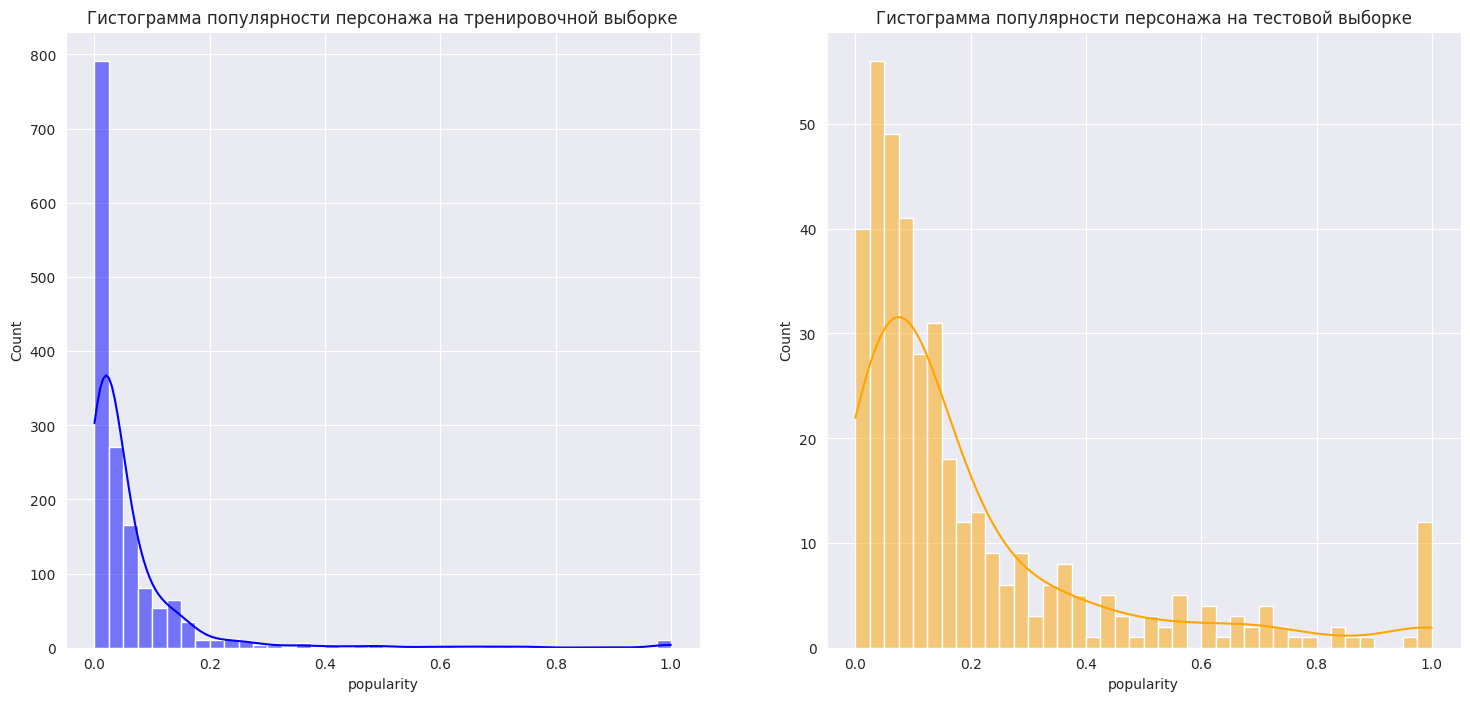

In [ ]:
_, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 8))
sns.histplot(data=train, x='popularity', kde=True, bins=40, ax=axes[0], color='blue')
sns.histplot(data=test, x='popularity', kde=True, bins=40, ax=axes[1], color='orange')
axes[0].set_title('Гистограмма популярности персонажа на тренировочной выборке')
axes[1].set_title('Гистограмма популярности персонажа на тестовой выборке')
plt.show()

Выводы:
- Оба распределения напоминают экспоненциальные, однако у тестовой выборки более выскоие бины, то есть там побольше популярных персонажей, чем на тестовой выборке

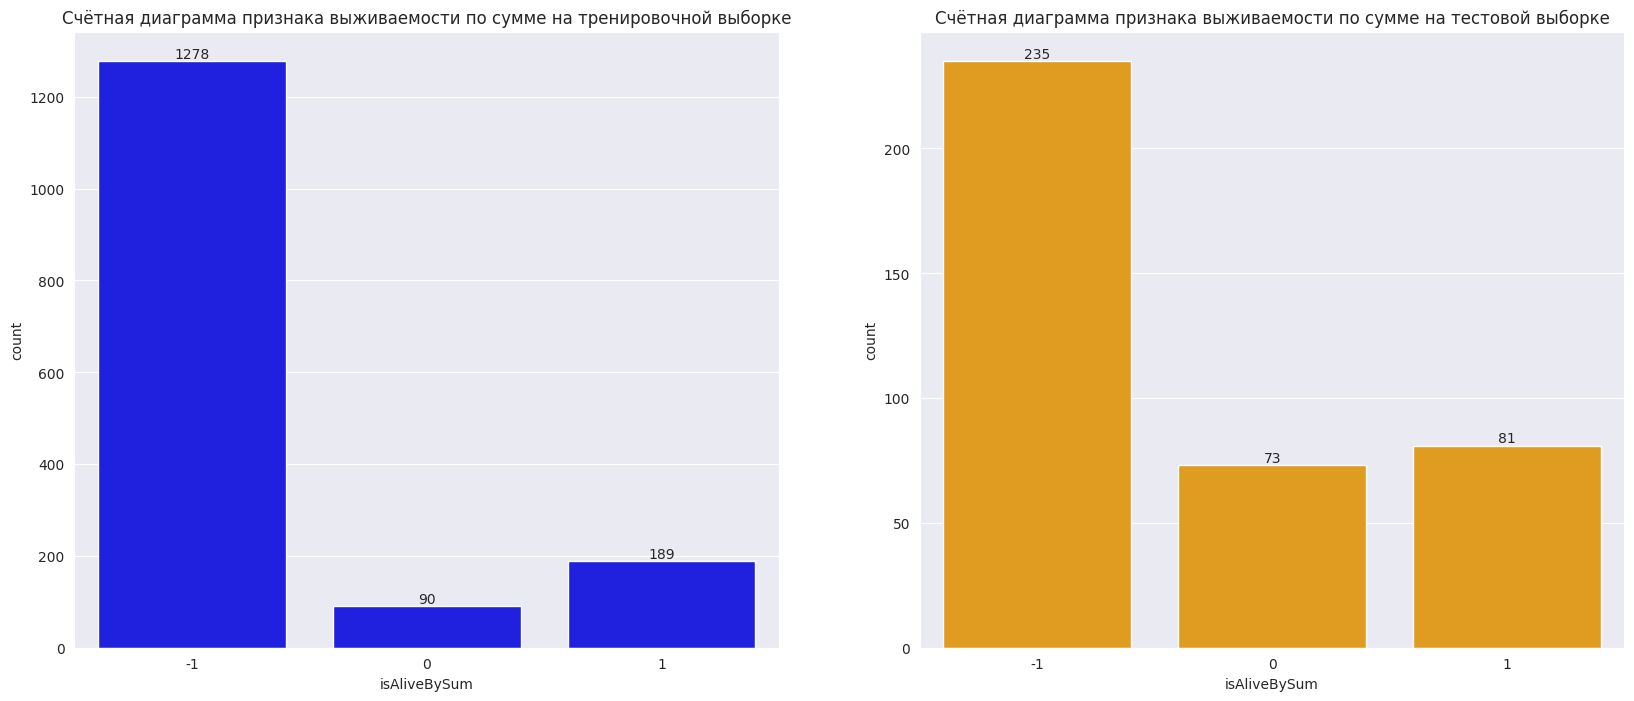

In [ ]:
_, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 8))
sorted_categories = sorted(train['isAliveBySum'].unique())
sns.countplot(data=train, x='isAliveBySum', order=sorted_categories, ax=axes[0], color='blue')
sns.countplot(data=test, x='isAliveBySum', order=sorted_categories, ax=axes[1], color='orange')
for i in range(2):
    axes[i].bar_label(axes[i].containers[0])
axes[0].set_title('Счётная диаграмма признака выживаемости по сумме на тренировочной выборке')
axes[1].set_title('Счётная диаграмма признака выживаемости по сумме на тестовой выборке')
plt.show()

Выводы:
- В целом, распределения схожи, однако на тестовой выборке нулеовй и единичный бин должны были бы быть ниже, причём нулевой в 2 раза п сравнению с единичным

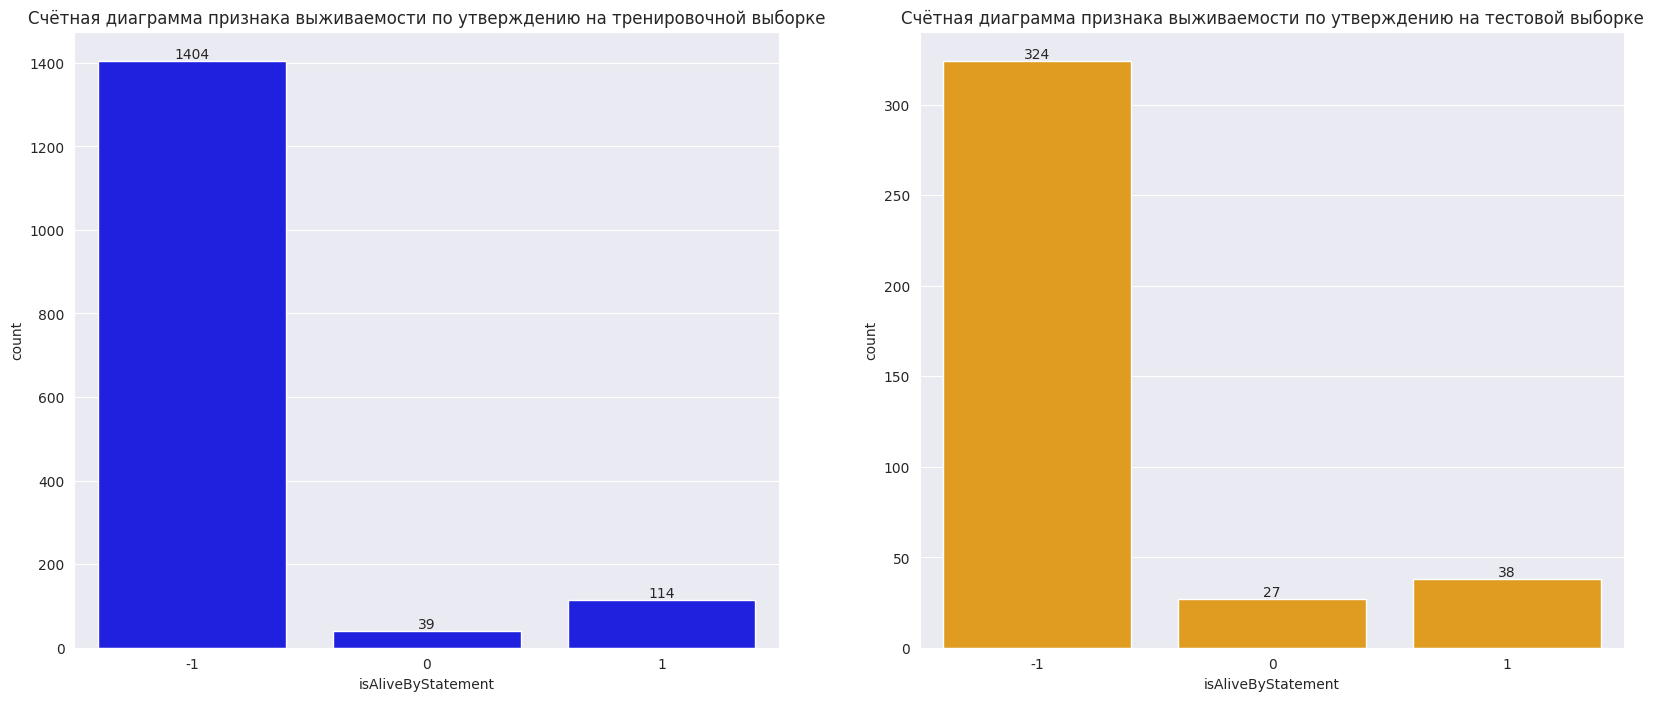

In [ ]:
_, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 8))
sorted_categories = sorted(train['isAliveByStatement'].unique())
sns.countplot(data=train, x='isAliveByStatement', order=sorted_categories, ax=axes[0], color='blue')
sns.countplot(data=test, x='isAliveByStatement', order=sorted_categories, ax=axes[1], color='orange')
for i in range(2):
    axes[i].bar_label(axes[i].containers[0])
axes[0].set_title('Счётная диаграмма признака выживаемости по утверждению на тренировочной выборке')
axes[1].set_title('Счётная диаграмма признака выживаемости по утверждению на тестовой выборке')
plt.show()

Выводы:
- Ситуация схожа с предыдущим пунктом, но в целом, она выглядит получше

## Подготовка к обучению

Итак, на тренирочоной и тестовой выборке для каких-то признаков распределения различаются немного, а для каких-то заметно, это нужно будет учитывать при обучении, так как обучившись на одном распределении признака, при предсказании модель столкнётся с другим и в таком случае это плохо скажется на результатах предсказания

Решение такое - присвоить каждому объекту вес, равный $\frac{P(test|x)}{P(train|x)}$, то есть числитель - вероятность того, что объект относится к тестовым данным, а знаментаель - что к тренировочным. Для получения этих вероятностей надо натренировать бинарный классификатор, который по исходным данным будет учиться отличать тренировочные данные от тестовых

На роль такого классификатора подойдёт CatBoost, так как для него не требуется обрабатывать категориальные признаки

In [ ]:
X = pd.concat([train.drop(columns='isAlive'), test])
y = pd.Series(np.concatenate([np.zeros(train.shape[0]), np.ones(test.shape[0])]).astype(int), index=X.index)
X

,title,male,culture,dateOfBirth,house,book1,book2,book3,book4,book5,firstBook,lastBook,isMarried,isNoble,age,numDeadRelations,popularity,isAliveBySum,isAliveByStatement
S.No,,,,,,,,,,,,,,,,,,,
1,Unknown,1,Unknown,247.0,House Targaryen,0,0,0,0,0,0,0,0,0,35.0,11,0.605351,-1,-1
2,Lord,1,Rivermen,208.0,House Frey,1,1,1,1,1,1,5,1,1,97.0,1,0.896321,1,1
3,Ser,1,Unknown,247.0,Other,0,0,0,1,0,4,4,0,1,35.0,0,0.267559,-1,-1
4,Queen,0,Unknown,82.0,House Arryn,0,0,0,0,0,0,0,1,1,23.0,0,0.183946,0,-1
5,Other,0,Dornish,276.0,Other,0,0,0,1,0,4,4,1,1,29.0,0,0.043478,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1942,Unknown,1,Westermen,247.0,House Stark,1,1,1,1,1,1,5,0,0,35.0,0,0.351171,-1,-1
1943,Unknown,1,Unknown,247.0,House Bolton,0,1,0,1,1,2,5,0,0,35.0,0,0.096990,-1,-1
1944,Unknown,1,Unknown,247.0,Unknown,1,1,1,1,1,1,5,0,0,35.0,0,0.030100,-1,-1


Определим категориальные столбцы, это нужно будет для CatBoost

In [ ]:
numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
categorical_columns = list(train.select_dtypes(exclude=numerics).columns)

Обучим классификатор, он не должен слишком хорошо различать выборки, просто указывать на какие-то значимые различия

In [ ]:
cb = CatBoostClassifier(n_estimators=500, eval_metric='Accuracy')
cb.fit(X, y, cat_features=categorical_columns)

Learning rate set to 0.025849
0:	learn: 0.8160329	total: 7.76ms	remaining: 3.87s
1:	learn: 0.8206578	total: 14.4ms	remaining: 3.58s
2:	learn: 0.8324769	total: 20ms	remaining: 3.31s
3:	learn: 0.8329908	total: 24.5ms	remaining: 3.03s
4:	learn: 0.8283659	total: 30ms	remaining: 2.97s
5:	learn: 0.8350462	total: 35.3ms	remaining: 2.9s
6:	learn: 0.8360740	total: 41.3ms	remaining: 2.91s
7:	learn: 0.8365879	total: 47.4ms	remaining: 2.92s
8:	learn: 0.8371017	total: 51.1ms	remaining: 2.79s
9:	learn: 0.8371017	total: 56.7ms	remaining: 2.78s
10:	learn: 0.8371017	total: 60.8ms	remaining: 2.7s
11:	learn: 0.8371017	total: 66.5ms	remaining: 2.71s
12:	learn: 0.8401850	total: 72.2ms	remaining: 2.7s
13:	learn: 0.8396711	total: 77.6ms	remaining: 2.69s
14:	learn: 0.8396711	total: 83.1ms	remaining: 2.69s
15:	learn: 0.8386434	total: 88.8ms	remaining: 2.69s
16:	learn: 0.8406989	total: 94.7ms	remaining: 2.69s
17:	learn: 0.8401850	total: 101ms	remaining: 2.69s
18:	learn: 0.8401850	total: 106ms	remaining: 2.69s
1

Теперь получим для тренировочных данных вероятности того, что они относятся к тестовым данным

In [ ]:
probs = cb.predict_proba(train)[:, 1]

Теперь получим, наконец, веса для тренировочных объектов объектов, а заодно отнормируем веса так, чтобы они в сумме давали 1

In [ ]:
weights = probs / (1 - probs)
weights /= weights.sum()

Эти модели не работают с категориальными признаками, поэтому их надо закодировать, в качестве кодировщика я возьму CatBoostEncoder, который в целом работает схожим образом с TargetEncoder-ом

In [ ]:
for column in categorical_columns:
    encoder = CatBoostEncoder()
    encoder.fit(train[column], train['isAlive'])
    for df in train, test:
        df[column] = encoder.transform(df[column])

Также необходимо отнормировать признаки до единого масштаба, это будет полезно для логистической регрессии, для ансамблевых же алгоритмов, которые работают над решающими деревьями, масштаб признков не важен

In [ ]:
scaler = StandardScaler()
train_scaled = pd.DataFrame(scaler.fit_transform(train.drop(columns='isAlive')), columns=test.columns, index=train.index)
test_scaled = pd.DataFrame(scaler.transform(test), columns=test.columns, index=test.index)
train_scaled['isAlive'] = train['isAlive']

Посмотрим на корреляцию между признаками на тренировочной выборке

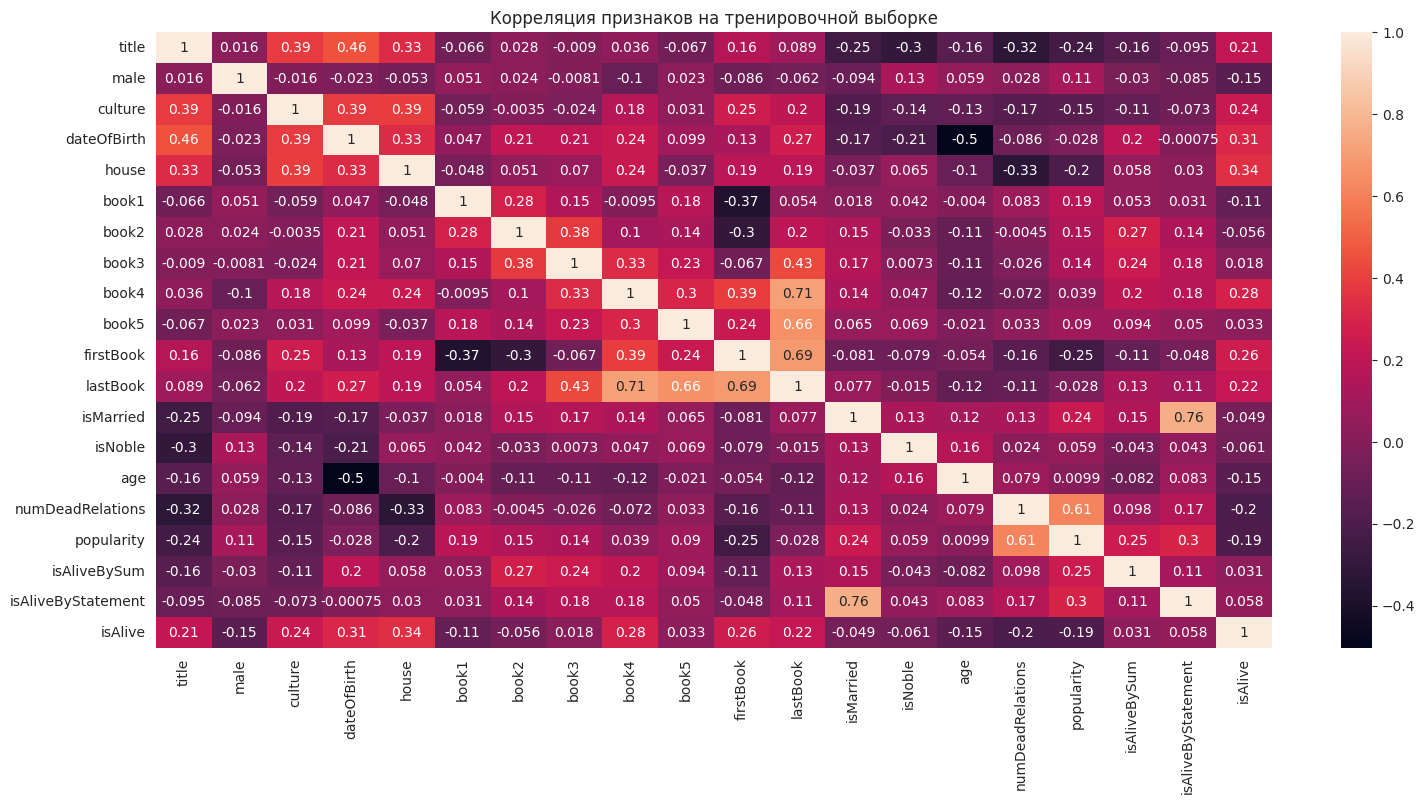

In [ ]:
_, ax = plt.subplots(figsize=(18, 8))
sns.heatmap(train_scaled.corr(), annot=True, ax=ax)
plt.title('Корреляция признаков на тренировочной выборке')
plt.show()

Выводы:
- Видим высокую положительную корреляцию между парами следующих признаков - выживаемости по утверждению и наличием супруга; последней книги, в которой появился персонаж и появился ли персонаж в четвёртой книге; последней книги и первой книги; последней книги и появился ли персонаж в 5 книге
- С целевой переменной самая высокая корреляция у признака фракции
- Максимальная по модулю отрицательная корреляция между возрастом и датой рождения

Теперь построим такую же таблицу и для тестовой выборки

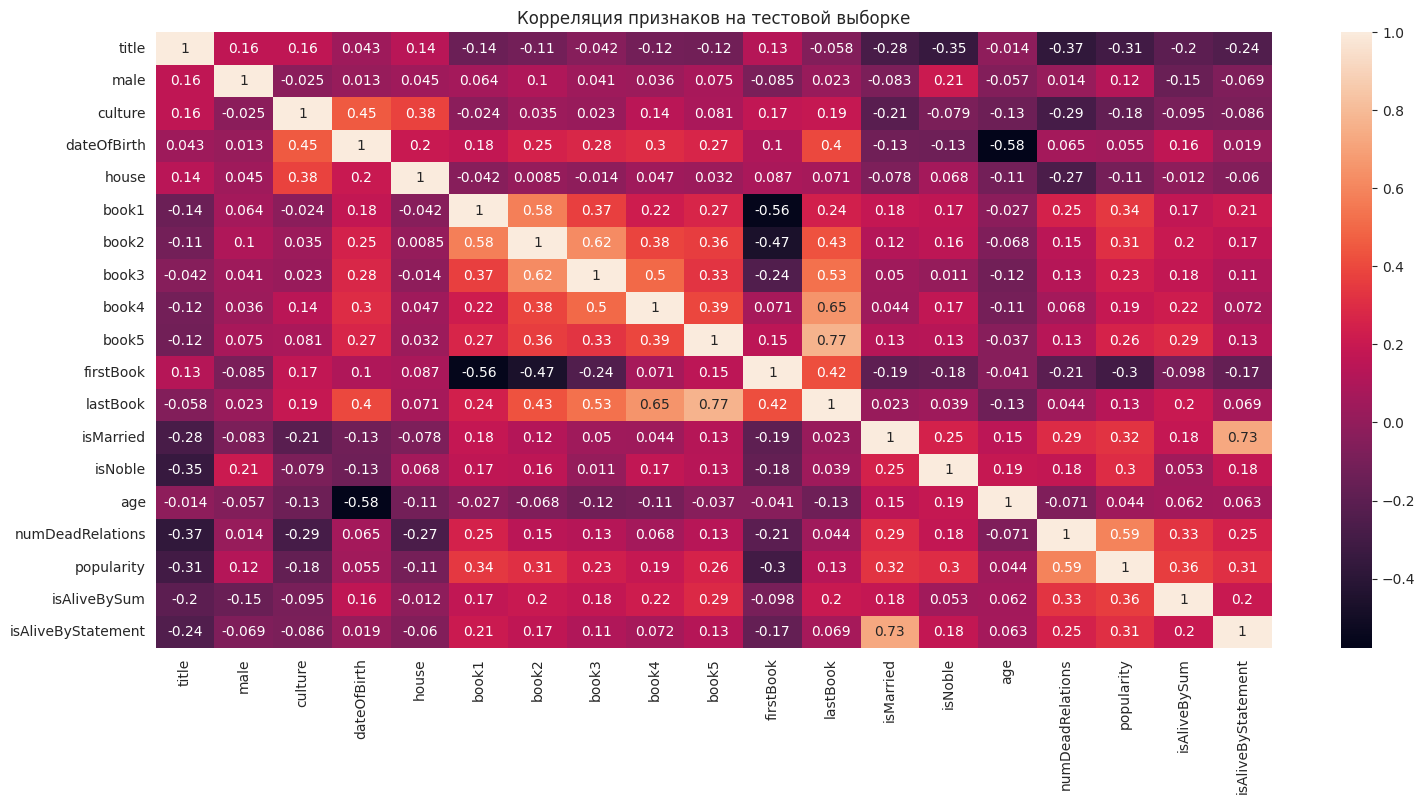

In [ ]:
_, ax = plt.subplots(figsize=(18, 8))
sns.heatmap(test_scaled.corr(), annot=True, ax=ax)
plt.title('Корреляция признаков на тестовой выборке')
plt.show()

Выводы:
- Высокая положительная корреляция между теме же парами признаков, что и на тренировочной выборке
- Максимальная по модулю отрицательная корреляция также между той же парой признаков
- Появляется достаточно высокая по модулю отрицательная корреляция между признаком первой книги и некоторыми другими признаками книг (book1, book2)

## Обучение моделей машинного обучения

Итак, нам нужны такие модели, которые в методе fit принимают параметр sample_weight (указываются веса для каждого объекта)

Итак, использоваться будут следующие модели:
- AdaBoostClassifier
- RandomForestClassifier
- BaggingClassifier

Разделим признаки и целевую переменную

In [ ]:
target = train['isAlive']
train = train.drop(columns='isAlive')

Для каждой модели с помощью фреймворка Optuna будут подбираться оптимальные гиперпараметры на кросс-валидации, для этого нужно написать отдельную функцию, которая будет принимать перебиремые параметры для модели и сохранять объект поиска в словарь results

In [ ]:
results = {}

In [ ]:
def search(params, n_trials, estimator, estimator_name):
    optuna_search = OptunaSearchCV(
        estimator=estimator,
        param_distributions=params,
        cv=StratifiedKFold(n_splits=5),
        n_trials=n_trials,
        scoring='accuracy',
        verbose=1
    )
    optuna_search.fit(train, target, sample_weight=weights)
    results[estimator_name] = optuna_search

Далее по очереди будем запускать подбор гиперпараметров для каждой из моделей

### AdaBoost

In [ ]:
estimator = DecisionTreeClassifier()
model = AdaBoostClassifier(estimator=estimator)
params = {
    'estimator__max_depth': optuna.distributions.IntDistribution(low=3, high=20),
    'estimator__min_samples_split': optuna.distributions.IntDistribution(low=2, high=20),
    'estimator__min_samples_leaf': optuna.distributions.IntDistribution(low=1, high=10),
    'estimator__criterion': optuna.distributions.CategoricalDistribution(['gini', 'entropy']),
    'n_estimators': optuna.distributions.IntDistribution(low=10, high=100),
    'learning_rate': optuna.distributions.FloatDistribution(low=1e-4, high=1e2, log=True)
}
search(params, 100, model, 'AdaBoost')

/tmp/ipython-input-465041224.py:2: ExperimentalWarning: OptunaSearchCV is experimental (supported from v0.17.0). The interface can change in the future.
  optuna_search = OptunaSearchCV(
[I 2025-08-05 12:09:33,182] A new study created in memory with name: no-name-05705443-bbff-4cec-b047-2e6c07ddb767
INFO:optuna_integration.sklearn.sklearn:Searching the best hyperparameters using 1557 samples...
[I 2025-08-05 12:09:35,218] Trial 0 finished with value: 0.8278712177426003 and parameters: {'estimator__max_depth': 8, 'estimator__min_samples_split': 10, 'estimator__min_samples_leaf': 10, 'estimator__criterion': 'entropy', 'n_estimators': 75, 'learning_rate': 0.0009116382672573253}. Best is trial 0 with value: 0.8278712177426003.
[I 2025-08-05 12:09:38,213] Trial 1 finished with value: 0.8362395910627421 and parameters: {'estimator__max_depth': 11, 'estimator__min_samples_split': 16, 'estimator__min_samples_leaf': 3, 'estimator__criterion': 'entropy', 'n_estimators': 68, 'learning_rate': 2.93

### Случайный лес

In [ ]:
model = RandomForestClassifier()
params = {
    'max_depth': optuna.distributions.IntDistribution(low=3, high=20),
    'min_samples_split': optuna.distributions.IntDistribution(low=2, high=20),
    'min_samples_leaf': optuna.distributions.IntDistribution(low=1, high=10),
    'n_estimators': optuna.distributions.IntDistribution(low=10, high=100),
    'criterion': optuna.distributions.CategoricalDistribution(['gini', 'entropy', 'log_loss'])
}
search(params, 100, model, 'RandomForest')

/tmp/ipython-input-465041224.py:2: ExperimentalWarning: OptunaSearchCV is experimental (supported from v0.17.0). The interface can change in the future.
  optuna_search = OptunaSearchCV(
[I 2025-08-05 12:13:31,557] A new study created in memory with name: no-name-feddda77-ec5b-4d79-98a6-504535916035
INFO:optuna_integration.sklearn.sklearn:Searching the best hyperparameters using 1557 samples...
[I 2025-08-05 12:13:32,884] Trial 0 finished with value: 0.8387851430455932 and parameters: {'max_depth': 7, 'min_samples_split': 6, 'min_samples_leaf': 2, 'n_estimators': 67, 'criterion': 'gini'}. Best is trial 0 with value: 0.8387851430455932.
[I 2025-08-05 12:13:34,143] Trial 1 finished with value: 0.8355635254349082 and parameters: {'max_depth': 5, 'min_samples_split': 19, 'min_samples_leaf': 5, 'n_estimators': 94, 'criterion': 'log_loss'}. Best is trial 0 with value: 0.8387851430455932.
[I 2025-08-05 12:13:34,880] Trial 2 finished with value: 0.8625422541017397 and parameters: {'max_depth':

### Бэггинг

In [ ]:
estimator = DecisionTreeClassifier()
model = BaggingClassifier(estimator=estimator)
params = {
    'estimator__max_depth': optuna.distributions.IntDistribution(low=3, high=20),
    'estimator__min_samples_split': optuna.distributions.IntDistribution(low=2, high=20),
    'estimator__min_samples_leaf': optuna.distributions.IntDistribution(low=1, high=10),
    'estimator__criterion': optuna.distributions.CategoricalDistribution(['gini', 'entropy']),
    'n_estimators': optuna.distributions.IntDistribution(low=10, high=100),
    'max_samples': optuna.distributions.FloatDistribution(low=0.5, high=1),
    'max_features': optuna.distributions.FloatDistribution(low=0.5, high=1),
}
search(params, 100, model, 'Bagging')

/tmp/ipython-input-465041224.py:2: ExperimentalWarning: OptunaSearchCV is experimental (supported from v0.17.0). The interface can change in the future.
  optuna_search = OptunaSearchCV(
[I 2025-08-05 12:15:20,260] A new study created in memory with name: no-name-98e0f036-3d89-4e8b-a3b8-547c8bd4b70c
INFO:optuna_integration.sklearn.sklearn:Searching the best hyperparameters using 1557 samples...
[I 2025-08-05 12:15:22,071] Trial 0 finished with value: 0.8561237529887048 and parameters: {'estimator__max_depth': 18, 'estimator__min_samples_split': 18, 'estimator__min_samples_leaf': 5, 'estimator__criterion': 'gini', 'n_estimators': 86, 'max_samples': 0.5851526341582453, 'max_features': 0.5581696426285474}. Best is trial 0 with value: 0.8561237529887048.
[I 2025-08-05 12:15:23,522] Trial 1 finished with value: 0.863834611262264 and parameters: {'estimator__max_depth': 20, 'estimator__min_samples_split': 3, 'estimator__min_samples_leaf': 7, 'estimator__criterion': 'entropy', 'n_estimators':

### Предсказание

На всякий случай, предскажем также результаты и каждым алгоритмом отдельно, вдруг какой-то один из них будет лучше ансамбля

In [ ]:
for key, value in results.items():
    preds = pd.Series(value.best_estimator_.predict(test), name='isAlive', index=test.index)
    preds.index.name = 'S.No'
    preds.to_csv(f'{key}.csv')

Каждый алгоритм будет иметь собственный коэффициент, пропорциональный результату на кросс-валидации у лучшего набора гиперпараметров, при этом сумма коэффициентов всех алгоритмов будет равняться 1

In [ ]:
coefs = {key: value.best_score_ for key, value in results.items()}
total = sum(coefs.values())
coefs = {key: value / total for key, value in coefs.items()}

Теперь составим датафрейм предсказаний

In [ ]:
preds = pd.DataFrame({
    key: value.best_estimator_.predict(test) for key, value in results.items()
}, index=test.index)
preds.index.name = 'S.No'
preds

,AdaBoost,RandomForest,Bagging
S.No,,,
1558,0,0,0
1559,0,1,1
1560,1,1,1
1561,1,1,1
1562,0,0,0
...,...,...,...
1942,0,0,0
1943,1,1,1
1944,1,1,1


Теперь умножим всё это на коэффициенты и сложим по первой оси

In [ ]:
for key, value in coefs.items():
    preds[key] = preds[key] * value

In [ ]:
preds = (preds.sum(axis=1) > 0.5).astype(int)
preds.name = 'isAlive'
preds

,isAlive
S.No,
1558,0
1559,1
1560,1
1561,1
1562,0
...,...
1942,0
1943,1
1944,1


Сохраним предсказания в CSV файл:

In [ ]:
preds.to_csv('submission.csv', index=False)

## Итоги

Самый лучший результат для ансамбля алгоритмов следующий (правильно предсказано 330 объектов из 389 на тестовой выборке):

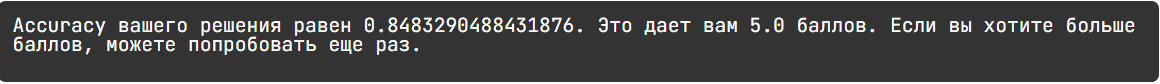

В большинстве случаев наилучшим алгоритмом являлся случайный лес, макимальный результат такой (правильно предсказан 331 объект из 389 на тестовой выборке):

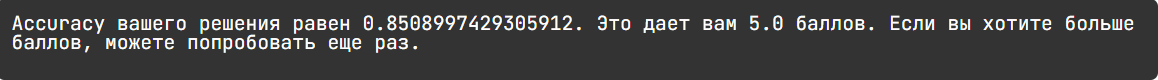

В целом, стоит выделить следующее:
- Если все 3 алгоритма выдавали примерно одинаковый accuracy, то ансамбль увеличивал его
- Если же два каких-то алгоритма были заметно лучше другого (accuracy была выше как минимум на 1), то ансамбль давал примерно такое же качество, как и два лучших алгоритма
- Ну а если только один алгоритм был замтено лучше других, то качество ансамбля было хуже качества лучшего алгоритма
- В различных экспериментах диапазон accuracy для алгоритмов был от 0.825 до 0.848, чаще всего было что-то среднее между этими двумя значениями